# **A Deep Dive Into IT Job Trends**
### ST1510 Programming for Data Analytics - CA1
#### Done By : **Balamurugan Siddhartha (DAAA/FT/1B/07)**
---

### **Background Information**

This assignment involves analysing a dataset of job postings to uncover meaningful patterns and trends in the job market. The data includes information such as job titles, salaries, locations, work types, and application counts. The goal is to use Pandas & MatPlotLib to explore and visualise these data points to provide insights into job postings and their popularity.

The context for this assignment revolves around an intern, Alex, who discovered a forgotten thumb drive with valuable job data. Tasked by the CEO to analyse this information, the aim is to uncover actionable insights that benefit both job seekers and recruiters.

### **Steps in Analysis**
1. **Background Research** : Investigate job market trends to define a focused research question and contextualise the data.

2. **Data Preparation** : Clean and organise the dataset using **Pandas**, including handling missing values, fixing inconsistencies, and preparing features such as dates and job descriptions for analysis.

3. **Exploratory Data Analysis (EDA)** : Identify key trends and patterns in the data, such as salary distributions, application counts, and job views.

4. **Data Visualisation** : Use **Matplotlib** to create professional visualisations that highlight insights.

5. **Gathering Insights** : Combine findings from the analysis to answer the research question and provide actionable conclusions.

By following these steps, I aim to answer my research question and provide deeper insights into the job market!


## **Research Question**

### <p style="font-family: 'Book Antiqua', serif;">*How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?*</p>

---

## Dataset Metadata

The job postings dataset contains comprehensive details about job listings, including job specifics, salaries, engagement metrics, and more. The summary below is adapted from the metadata provided on **Brightspace**.

### **1. Job Details**

- `job_id`: Unique job identifier.

- `title`: Job title.

- `description`: Job role details.

- `location`: Job location.

- `formatted_work_type`: Work type (e.g., Full-time, Part-time, Contract).

- `work_type`: Additional work-related details.

- `remote_allowed`: Indicates if remote work is allowed.

---

### **2. Salary Information**

- `max_salary`, `med_salary`, `min_salary`: Salary range for the job.

- `pay_period`: Salary frequency (Hourly, Monthly, Yearly).

- `currency`: Salary currency.

- `compensation_type`: Type of compensation offered.

---

### **3. Engagement Metrics**

- `applies`: Number of applications submitted.

- `views`: Number of job listing views.

---

### **4. Application and Posting Information**

- `job_posting_url`, `application_url`: URLs for the job posting and application submission.

- `application_type`: Application process type (e.g., offsite, simple onsite, complex).

- `listed_time`, `original_listed_time`: Time when the job was listed.

- `expiry`, `closed_time`: Expiry and closure dates of the job posting.

---

### **5. Experience and Skills**

- `formatted_experience_level`: Required experience level (Entry, Associate, Executive, etc.).

- `skills_desc`: Detailed description of required skills.

---

### **6. Additional Metadata**

- `company_id`: Company identifier linked to the job.

- `posting_domain`: Website hosting the job listing.

- `sponsored`: Indicates if the job posting is promoted.

---

This metadata provides a structured foundation for analysing job trends, application behaviours, and skill demands in the job market.

## **Next Steps**

1. Perform cleaning and transformation on all datasets to standardise formats and handle missing or inconsistent data.
2. Merge the datasets where applicable, using `job_id` as the primary key.
3. Conduct exploratory analysis and visualisation to answer the research question.
4. Derive insights and summarise findings for actionable recommendations.


#### Importing Libraries

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

#### Importing Datafiles

In [80]:
postings_1 = pd.read_csv('data/postings1.csv', index_col='job_id')
postings_2 = pd.read_csv('data/postings2.csv', index_col='job_id')
postings_3 = pd.read_csv('data/postings3.csv', index_col='job_id')
postings_4 = pd.read_csv('data/postings4.csv', index_col='job_id')
postings_5 = pd.read_excel('data/postings5.xlsx', index_col='job_id')


## **Viewing the first few rows of the dataset**
---

### **Postings_1 Dataset Overview**
---

In [81]:
postings_1.head()

,company_name,title
job_id,,
921716,Corcoran Sawyer Smith,Marketing Coordinator
1829192,NaN,Mental Health Therapist/Counselor
10998357,The National Exemplar,Assitant Restaurant Manager
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...
35982263,NaN,Service Technician



- **Columns**:
  - `job_id`: A unique identifier for each job posting.
  - `company_name`: The name of the company posting the job.
  - `title`: The job title being advertised.

- **Key Points**:
  - Each row represents a unique job posting, identified by `job_id`.
  - Some entries in `company_name` are missing (`NaN`), indicating the need for data cleaning.
  - Job titles are diverse and descriptive, including roles such as *Marketing Coordinator*, *Service Technician*, and *Mental Health Therapist/Counselor*.

- **Next Steps**:
  - Handle missing `company_name` values by replacing them with placeholders (e.g., "Unknown Company") or excluding them if necessary.
  - Conduct an analysis of job titles to identify trends, common keywords, or high-demand roles.


### **Postings_2 Dataset Overview**
---

In [82]:
postings_2.head()

,description,max_salary
job_id,,
921716,Job descriptionA leading real estate firm in N...,20
1829192,"At Aspen Therapy and Wellness , we are committ...",50
10998357,The National Exemplar is accepting application...,"65,000"
23221523,Senior Associate Attorney - Elder Law / Trusts...,"175,000"
35982263,Looking for HVAC service tech with experience ...,"80,000"


- **Columns**:
  - `job_id`: A unique identifier for each job posting.
  - `description`: A detailed description of the job and its requirements.
  - `max_salary`: The maximum salary offered for the role.

- **Key Points**:
  - Each row represents a unique job posting, identified by `job_id`.
  - `description` provides context about the job and company, e.g., *"A leading real estate firm..."* or *"Looking for HVAC service tech with experience...".*
  - The `max_salary` column indicates salary ranges, with values varying significantly (e.g., $20.00 to $175,000.00).

- **Next Steps**:
  - Clean and standardise `description` text to extract relevant keywords for analysis (e.g., skills or job role focus).
  - Analyse the distribution of `max_salary` to identify trends or outliers and link salary data to job roles or descriptions.


### **Postings_3 Dataset Overview**
---

In [83]:
postings_3.head()

,pay_period,location,company_id,views,med_salary,min_salary
job_id,,,,,,
921716,HOURLY,"Princeton, NJ","2,774,458",20,NaN,17
1829192,HOURLY,"Fort Collins, CO",NaN,1,NaN,30
10998357,YEARLY,"Cincinnati, OH","64,896,719",8,NaN,"45,000"
23221523,YEARLY,"New Hyde Park, NY","766,262",16,NaN,"140,000"
35982263,YEARLY,"Burlington, IA",NaN,3,NaN,"60,000"


- **Columns**:
  - `job_id`: A unique identifier for each job posting.
  - `pay_period`: Indicates the payment frequency (e.g., HOURLY, YEARLY).
  - `location`: The city and state of the job posting.
  - `company_id`: A unique identifier for the company posting the job.
  - `views`: The number of views the job posting has received.
  - `med_salary`: The median salary offered for the job.
  - `min_salary`: The minimum salary offered for the job.

- **Key Points**:
  - The dataset includes information on job location and pay structure.
  - Missing values are present in `company_id`, `med_salary`, and `min_salary`, indicating the need for data cleaning.
  - `pay_period` varies between HOURLY and YEARLY, reflecting different job types and compensation structures.
  - Salary ranges show significant variation, with minimum salaries as low as $17 and median salaries missing for some entries.
  - `views` provide engagement metrics, revealing the popularity of job postings (e.g., some postings have very few views).

- **Next Steps**:
  - Handle missing values in `company_id`, `med_salary`, and `min_salary` through imputation or dropping.
  - Analyse salary trends by `pay_period` and `location` to uncover geographical and compensation patterns.
  - Investigate the correlation between `views` and other variables (e.g., `location`, `salary`) to identify factors influencing job popularity.


### **Postings_4 Dataset Overview**
---

In [84]:
postings_4.head()

,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
job_id,,,,,,,,,,,,,,,,,
921716,Full-time,2,"1,713,400,000,000",NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,"1,715,990,000,000",NaN,NaN,Requirements: \n\nWe are seeking a College or ...,"1,713,400,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
1829192,Full-time,NaN,"1,712,860,000,000",NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,"1,715,450,000,000",NaN,NaN,NaN,"1,712,860,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
10998357,Full-time,NaN,"1,713,280,000,000",NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,"1,715,870,000,000",NaN,NaN,We are currently accepting resumes for FOH - A...,"1,713,280,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
23221523,Full-time,NaN,"1,712,900,000,000",NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,"1,715,490,000,000",NaN,NaN,This position requires a baseline understandin...,"1,712,900,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
35982263,Full-time,NaN,"1,713,450,000,000",NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,"1,716,040,000,000",NaN,NaN,NaN,"1,713,450,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY


- **Columns**:
  - `formatted_work_type`: Indicates the job's work type (e.g., Full-time).
  - `applies`: The number of applications submitted for the job.
  - `original_listed_time`: Timestamp for when the job was originally listed.
  - `remote_allowed`: Indicates if remote work is permitted.
  - `job_posting_url`: URL linking to the job posting.
  - `application_url`: URL for submitting applications.
  - `application_type`: Type of application process (e.g., ComplexOnsiteApply).
  - `expiry`: Timestamp for when the job posting expires.
  - `closed_time`: Timestamp for when the job listing closed.
  - `formatted_experience_level`: Required experience level for the job (e.g., Entry, Mid, Senior).
  - `skills_desc`: Description of required skills for the job.
  - `listed_time`: Timestamp for when the job was listed.
  - `posting_domain`: The domain of the platform hosting the job listing.
  - `sponsored`: Indicates if the job posting is sponsored.
  - `work_type`: Type of work (e.g., FULL_TIME).
  - `currency`: Currency in which the salary is paid (e.g., USD).
  - `compensation_type`: Type of compensation (e.g., BASE_SALARY).

- **Key Points**:
  - The dataset provides extensive metadata on job postings, including timestamps (`original_listed_time`, `expiry`, `closed_time`) and job application metrics (`applies`, `application_type`).
  - Missing values are present in key columns like `applies`, `remote_allowed`, `skills_desc`, and `posting_domain`, requiring data cleaning.
  - The majority of job postings are `Full-time` and compensated in `USD` with `BASE_SALARY`.
  - Skills descriptions vary in detail, highlighting specific requirements for certain roles (e.g., *"baseline understanding of elder law"*).

- **Next Steps**:
  - Address missing values in `applies`, `remote_allowed`, and `skills_desc` to improve analysis.
  - Analyse job application trends by `formatted_work_type`, `application_type`, and `remote_allowed`.
  - Extract and analyse keywords from `skills_desc` to identify commonly sought-after skills.
  - Investigate the relationship between `applies`, `work_type`, and `formatted_experience_level` to determine what drives job application rates.


### **Postings_5 Dataset Overview**
---


In [85]:
postings_5.head()

,company_name,title,Easter Egg,Unimportant Column
job_id,,,,
921716,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1
1829192,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1
10998357,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1
35982263,NaN,Service Technician,"In order to score well for this module, you sh...",1



- **Columns**:
  - `company_name`: Name of the company posting the job.
  - `title`: The advertised job title.
  - `Easter Egg`: A hint or additional information column (e.g., *"In order to score well for this module, you should..."*).
  - `Unimportant Column`: A placeholder column with identical values.

### ***We can see that `Postings_5` is basically `Postings_1` but with two additional columns, **Easter Egg** & **Unimportant Column**!***

- **Key Points**:
  - Some entries in `company_name` are missing, suggesting the need for data cleaning.
  - The `title` column includes diverse job roles such as *Marketing Coordinator* and *Service Technician*.
  - The `Easter Egg` column provides advice, hinting at steps to excel in this module (possibly for engagement or context).
  - The `Unimportant Column` contains a constant value of `1.0` and likely serves no analytical purpose.

- **Next Steps**:
  - Address missing values in `company_name`.
  - Drop the `Unimportant Column` & `Easter Egg`columns during preprocessing!
  - Use the `title` column to explore job trends or frequently advertised roles.

## **Checking basic information of the datasets : Datatypes & Shape**
---

### **Postings_1 Dataset Summary**
---

In [86]:
# Check basic information for Postings 1
print("Postings 1 Info:")
postings_1.info()


Postings 1 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 123849 entries, 921716 to 3906267224
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   company_name  122130 non-null  object
 1   title         123849 non-null  object
dtypes: object(2)
memory usage: 2.8+ MB


- The dataset contains **123,849 entries** across **2 columns**: `company_name` and `title`.
- The `company_name` column has **122,130 non-null values**, indicating some missing data.
- The `title` column is fully populated with **123,849 non-null values**, providing a complete set of job titles.
- Both columns have a data type of `object`, meaning they contain textual data.
- Insights:
  - Missing values in `company_name` should be addressed during data cleaning.
  - `title` can be analysed to identify trends in job roles or popular keywords.

### **Postings_2 Dataset Summary**
---

In [87]:
# Check basic information for Postings 2
print("Postings 2 Info:")
postings_2.info()


Postings 2 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 123849 entries, 921716 to 3906267224
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   description  123842 non-null  object 
 1   max_salary   29793 non-null   float64
dtypes: float64(1), object(1)
memory usage: 2.8+ MB


- The dataset contains **123,849 entries** across **2 columns**: `description` and `max_salary`.
- The `description` column has **123,842 non-null values**, meaning a small number of entries are missing job descriptions.
- The `max_salary` column has only **29,793 non-null values**, indicating significant missing data that requires attention.
- Data types:
  - `description`: `object` (textual data).
  - `max_salary`: `float64` (numerical data).
- Insights:
  - Missing data in `max_salary` needs to be addressed, potentially through imputation or exclusion for analysis.
  - `description` can be processed to extract keywords or perform sentiment analysis.

### **Postings_3 Dataset Summary**
---

In [88]:
# Check basic information for Postings 3
print("Postings 3 Info:")
postings_3.info()


Postings 3 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 123849 entries, 921716 to 3906267224
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   pay_period  36073 non-null   object 
 1   location    123849 non-null  object 
 2   company_id  122132 non-null  float64
 3   views       122160 non-null  float64
 4   med_salary  6280 non-null    float64
 5   min_salary  29793 non-null   float64
dtypes: float64(4), object(2)
memory usage: 6.6+ MB


- The dataset contains **123,849 entries** across **6 columns**: `pay_period`, `location`, `company_id`, `views`, `med_salary`, and `min_salary`.
- Non-null counts:
  - `pay_period`: **36,073 non-null values** (significant missing data).
  - `location`: Fully populated with **123,849 non-null values**.
  - `company_id`: **122,132 non-null values** (minimal missing data).
  - `views`: **122,160 non-null values** (minor missing data).
  - `med_salary`: **6,280 non-null values** (majority missing data).
  - `min_salary`: **29,793 non-null values** (significant missing data).
- Data types:
  - `pay_period` and `location`: `object` (textual data).
  - `company_id`, `views`, `med_salary`, `min_salary`: `float64` (numerical data).
- Insights:
  - Missing data in `pay_period`, `med_salary`, and `min_salary` suggests these columns require cleaning or imputation.
  - `location` is fully populated and can be used for geographic analysis.
  - `views` can provide insights into the popularity of job postings.

### **Postings_4 Dataset Summary**
---

In [89]:
# Check basic information for Postings 4
print("Postings 4 Info:")
postings_4.info()


Postings 4 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 123849 entries, 921716 to 3906267224
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   formatted_work_type         123849 non-null  object 
 1   applies                     23320 non-null   float64
 2   original_listed_time        123849 non-null  float64
 3   remote_allowed              15246 non-null   float64
 4   job_posting_url             123849 non-null  object 
 5   application_url             87184 non-null   object 
 6   application_type            123849 non-null  object 
 7   expiry                      123849 non-null  float64
 8   closed_time                 1073 non-null    float64
 9   formatted_experience_level  94440 non-null   object 
 10  skills_desc                 2439 non-null    object 
 11  listed_time                 123849 non-null  float64
 12  posting_domain              83881 non-null   object

- The dataset contains **123,849 entries** across **17 columns**.
- **Non-null Counts**:
  - Fully populated columns: `formatted_work_type`, `original_listed_time`, `job_posting_url`, `application_type`, `expiry`, `listed_time`, `sponsored`, and `work_type`.
  - Sparse columns include:
    - `applies`: **23,320 non-null values**.
    - `remote_allowed`: **15,246 non-null values**.
    - `application_url`: **87,184 non-null values**.
    - `formatted_experience_level`: **94,440 non-null values**.
    - `skills_desc`: Only **2,439 non-null values**.
    - `currency` and `compensation_type`: **36,073 non-null values**.
    - `closed_time`: Only **1,073 non-null values**.
  - `posting_domain`: **83,881 non-null values**.
- **Data Types**:
  - `object`: **10 columns** (e.g., textual data like `formatted_work_type`, `skills_desc`).
  - `float64`: **6 columns** (e.g., `applies`, `remote_allowed`, `expiry`).
  - `int64`: **1 column** (`sponsored`).

- **Insights**:
  - Missing data is extensive in key columns like `applies`, `remote_allowed`, and `skills_desc`, requiring cleaning or imputation.
  - Fully populated columns like `work_type` and `application_type` can provide consistent insights.
  - The `skills_desc` column could reveal job-specific requirements but needs significant preprocessing due to sparse data.
  - Engagement metrics (`applies`, `remote_allowed`) and timestamps (`listed_time`, `expiry`) can be leveraged for trend analysis.


### **Postings_5 Dataset Summary**
---

In [90]:
# Check basic information for Postings 5
print("Postings 5 Info:")
postings_5.info()


Postings 5 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 123849 entries, 921716 to 3906267224
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   company_name        122130 non-null  object 
 1   title               123849 non-null  object 
 2   Easter Egg          8808 non-null    object 
 3   Unimportant Column  4177 non-null    float64
dtypes: float64(1), object(3)
memory usage: 4.7+ MB


- The dataset contains **123,849 entries** across **4 columns**: `company_name`, `title`, `Easter Egg`, and `Unimportant Column`.

- **Non-null Counts**:
  - `company_name`: **122,130 non-null values**, with some missing data.
  - `title`: Fully populated with **123,849 non-null values**.
  - `Easter Egg`: Only **8,808 non-null values**, indicating sparse data.
  - `Unimportant Column`: Highly sparse, with only **4,177 non-null values**.

- **Data Types**:
  - `object`: **3 columns** (`company_name`, `title`, `Easter Egg`).
  - `float64`: **1 column** (`Unimportant Column`).

- **Memory Usage**: Approximately **4.7 MB**.

- **Insights**:
  - `company_name` and `title` provide core job posting information but require cleaning for missing values in `company_name`.
  - The `Easter Egg` column appears to contain hints or additional metadata but is highly incomplete.
  - `Unimportant Column` likely holds negligible value for analysis due to its sparsity and potential irrelevance.
  - Further processing is needed to determine whether to exclude or leverage sparse columns (`Easter Egg` and `Unimportant Column`) in the analysis.


## **Checking missing values of the datasets**
---

### **Missing Values in Postings_1**
---

In [91]:
# Check missing values in Postings 1
print("Missing Values in Postings 1:")
print(postings_1.isnull().sum())


Missing Values in Postings 1:
company_name    1719
title              0
dtype: int64


- The `company_name` column has **1,719 missing values**, indicating some job postings lack company information.
- The `title` column is fully populated with **0 missing values**.
- Action: Address the missing values in `company_name` by filling with placeholders (e.g., "Unknown") or excluding those rows if necessary.

### **Missing Values in Postings_2**
---

In [92]:
# Check missing values in Postings 2
print("Missing Values in Postings 2:")
print(postings_2.isnull().sum())


Missing Values in Postings 2:
description        7
max_salary     94056
dtype: int64


- The `description` column has **7 missing values**, suggesting minor gaps in job descriptions.
- The `max_salary` column has **94,056 missing values**, indicating significant sparsity in salary data.
- Action: Handle missing `description` values by filling with placeholders or excluding rows. Address missing `max_salary` values through imputation, analysis without this column, or filtering complete entries.

### **Missing Values in Postings_3**
---

In [93]:
# Check missing values in Postings 3
print("Missing Values in Postings 3:")
print(postings_3.isnull().sum())


Missing Values in Postings 3:
pay_period     87776
location           0
company_id      1717
views           1689
med_salary    117569
min_salary     94056
dtype: int64


- **Columns with Missing Values**:
  - `pay_period`: **87,776 missing values**, indicating sparse data about payment frequency.
  - `company_id`: **1,717 missing values**, reflecting incomplete company information.
  - `views`: **1,689 missing values**, impacting engagement analysis.
  - `med_salary`: **117,569 missing values**, making this column highly sparse.
  - `min_salary`: **94,056 missing values**, similar sparsity as `med_salary`.

- **Columns Without Missing Values**:
  - `location` is fully populated with **0 missing values**.

- **Action**:
  - Focus on cleaning essential columns (`pay_period`, `company_id`, `views`) for further analysis.
  - Consider excluding or imputing `med_salary` and `min_salary` depending on their relevance to the research question.

### **Missing Values in Postings_4**
---

In [94]:
# Check missing values in Postings 4
print("Missing Values in Postings 4:")
print(postings_4.isnull().sum())


Missing Values in Postings 4:
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
compensation_type              87776
dtype: int64


- **Columns with Missing Values**:
  - `applies`: **100,529 missing values**, showing a lack of application data for most job postings.
  - `remote_allowed`: **108,603 missing values**, limiting insights into remote work options.
  - `application_url`: **36,665 missing values**, affecting the ability to analyse job application links.
  - `closed_time`: **122,776 missing values**, making it almost entirely unavailable.
  - `formatted_experience_level`: **29,409 missing values**, impacting insights into required experience levels.
  - `skills_desc`: **121,410 missing values**, rendering skills data nearly unusable.
  - `posting_domain`: **39,968 missing values**, limiting information about the source platform.
  - `currency` and `compensation_type`: **87,776 missing values**, leaving payment details incomplete.

- **Columns Without Missing Values**:
  - Fully populated columns include: `formatted_work_type`, `original_listed_time`, `job_posting_url`, `application_type`, `expiry`, `listed_time`, `sponsored`, and `work_type`.

- **Action**:
  - Focus analysis on fully populated columns and consider excluding or imputing sparse columns like `skills_desc` and `closed_time`.
  - Explore relationships between well-filled columns (`formatted_work_type`, `application_type`) and target variables.
  - Investigate patterns in missing data for strategic imputation, especially for `applies` and `remote_allowed`.

### **Missing Values in Postings_5**
---

In [95]:
# Check missing values in Postings 5
print("Missing Values in Postings 5:")
print(postings_5.isnull().sum())


Missing Values in Postings 5:
company_name            1719
title                      0
Easter Egg            115041
Unimportant Column    119672
dtype: int64


- **Columns with Missing Values**:
  - `company_name`: **1,719 missing values**, indicating gaps in company information.
  - `Easter Egg`: **115,041 missing values**, making this column largely unusable.
  - `Unimportant Column`: **119,672 missing values**, rendering it nearly irrelevant for analysis.

- **Columns Without Missing Values**:
  - `title` is fully populated with **0 missing values**.

- **Action**:
  - Address missing `company_name` values by imputing placeholders (e.g., "Unknown") or filtering rows with complete data.
  - Exclude `Easter Egg` and `Unimportant Column` from analysis due to high sparsity unless they serve a specific purpose.
  - Focus analysis on the fully populated `title` column to explore trends in job roles.

## Defining A Function For Comprehensive Data Insights (`dataset_summary`)
---

In the cell below, the function `dataset_summary(df, name="Dataset")` is defined to provide a comprehensive overview of a dataset:

1. **Dataset Shape**: Displays the number of rows and columns.
2. **Column Info**: Lists each column with its data type, unique values, and percentage of missing data.
3. **Numeric Statistics**: Shows summary statistics (mean, min, max, etc.) for numeric columns along with missing data information.
4. **Missing Data Insights**: Displays total missing values and the percentage of missing data in the dataset.
5. **Dataset Preview**: Shows the first few rows of the dataset for a quick preview.


In [96]:
def dataset_summary(df, name="Dataset"):
    print(f"\n{'='*60}")
    print(f"Summary of {name}")
    print(f"{'='*60}\n")
    
    print(f"Shape of the dataset: {df.shape[0]} rows and {df.shape[1]} columns.\n")
    
    # Display column info: data type, unique values, missing data percentage
    print(f"{'-'*60}")
    print("Column Information:\n")
    print(f"{'Index':<10}{'Column Name':<30}{'Data Type':<15}{'Unique Values':<20}{'Missing (%)':<15}")
    print(f"{'-'*60}")
    
    for i, col in enumerate(df.columns):
        unique_vals = df[col].nunique()
        missing_vals = df[col].isnull().sum()
        missing_perc = (missing_vals / len(df)) * 100
        dtype = df[col].dtype
        print(f"{i+1:<10}{col:<30}{str(dtype):<15}{unique_vals:<20}{missing_perc:.2f}%")
    
    # Display numeric column statistics
    print(f"\n{'-'*60}")
    print("Basic Statistics for Numeric Columns:\n")
    
    numeric_stats = df.describe().transpose()
    numeric_stats['missing'] = df.isnull().sum()
    numeric_stats['missing (%)'] = (df.isnull().sum() / len(df)) * 100
    numeric_stats = numeric_stats.sort_values(by='missing (%)', ascending=False)  # Sort by missing percentage
    display(numeric_stats)
    
    print(f"{'-'*60}")
    print(f"General Insights:")
    print(f"Total Missing Values in the Dataset: {df.isnull().sum().sum()}")
    print(f"Percentage of Missing Data: {(df.isnull().sum().sum() / df.size) * 100:.2f}%\n")
    print(f"Preview of the Dataset:\n")
    display(df.head())
    print(f"{'='*60}")


In [97]:
dataframes = [postings_1, postings_2, postings_3, postings_4, postings_5]
names = ["Postings 1", "Postings 2", "Postings 3", "Postings 4", "Postings 5"]

# Using a for loop with zip to iterate through two arrays!
for df, name in zip(dataframes, names):
    dataset_summary(df, name=name)
    print("\n")



Summary of Postings 1

Shape of the dataset: 123849 rows and 2 columns.

------------------------------------------------------------
Column Information:

Index     Column Name                   Data Type      Unique Values       Missing (%)    
------------------------------------------------------------
1         company_name                  object         24428               1.39%
2         title                         object         72521               0.00%

------------------------------------------------------------
Basic Statistics for Numeric Columns:



,count,unique,top,freq,missing,missing (%)
company_name,122130,24428,Liberty Healthcare and Rehabilitation Services,1108,1719,1
title,123849,72521,Sales Manager,673,0,0


------------------------------------------------------------
General Insights:
Total Missing Values in the Dataset: 1719
Percentage of Missing Data: 0.69%

Preview of the Dataset:



,company_name,title
job_id,,
921716,Corcoran Sawyer Smith,Marketing Coordinator
1829192,NaN,Mental Health Therapist/Counselor
10998357,The National Exemplar,Assitant Restaurant Manager
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...
35982263,NaN,Service Technician





Summary of Postings 2

Shape of the dataset: 123849 rows and 2 columns.

------------------------------------------------------------
Column Information:

Index     Column Name                   Data Type      Unique Values       Missing (%)    
------------------------------------------------------------
1         description                   object         107826              0.01%
2         max_salary                    float64        5321                75.94%

------------------------------------------------------------
Basic Statistics for Numeric Columns:



...

,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
job_id,,,,,,,,,,,,,,,,,
921716,Full-time,2,"1,713,400,000,000",NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,"1,715,990,000,000",NaN,NaN,Requirements: \n\nWe are seeking a College or ...,"1,713,400,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
1829192,Full-time,NaN,"1,712,860,000,000",NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,"1,715,450,000,000",NaN,NaN,NaN,"1,712,860,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
10998357,Full-time,NaN,"1,713,280,000,000",NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,"1,715,870,000,000",NaN,NaN,We are currently accepting resumes for FOH - A...,"1,713,280,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
23221523,Full-time,NaN,"1,712,900,000,000",NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,"1,715,490,000,000",NaN,NaN,This position requires a baseline understandin...,"1,712,900,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY
35982263,Full-time,NaN,"1,713,450,000,000",NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,"1,716,040,000,000",NaN,NaN,NaN,"1,713,450,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY





Summary of Postings 5

Shape of the dataset: 123849 rows and 4 columns.

------------------------------------------------------------
Column Information:

Index     Column Name                   Data Type      Unique Values       Missing (%)    
------------------------------------------------------------
1         company_name                  object         24428               1.39%
2         title                         object         72521               0.00%
3         Easter Egg                    object         1                   92.89%
4         Unimportant Column            float64        1                   96.63%

------------------------------------------------------------
Basic Statistics for Numeric Columns:



,count,mean,std,min,25%,50%,75%,max,missing,missing (%)
Unimportant Column,"4,177",1,0,1,1,1,1,1,119672,97


------------------------------------------------------------
General Insights:
Total Missing Values in the Dataset: 236432
Percentage of Missing Data: 47.73%

Preview of the Dataset:



,company_name,title,Easter Egg,Unimportant Column
job_id,,,,
921716,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1
1829192,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1
10998357,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1
35982263,NaN,Service Technician,"In order to score well for this module, you sh...",1


## Sorting Datasets Using `sort_values` & `groupby` Function

---

Sorting datasets is a crucial step in data analysis to prioritise key trends or values. By using the `sort_values` function in pandas, I can efficiently organise the data based on specific criteria such as job postings, salary, or views. Sorting helps us uncover underlying patterns and identify the most important or frequent data points.

In this step, I will sort the dataset to examine which columns are most relevant for the research question, particularly focusing on **experience level**, **salary**, and **views**. This helps me identify key trends and improve the analysis for further exploration.


### Sorting Top 10 `max_salary` in Postings_2
---

Sorting by `max_salary` before merging allows us to analyse the highest compensation offered across all job postings. This helps identify salary trends, which are crucial to **understanding how salaries vary by geographic location, work type, and experience level, in relation to the research question**.


In [98]:
# Sorting postings_2 by 'max_salary' in descending order
postings_2_sorted = postings_2.sort_values(by='max_salary', ascending=False)

postings_2_sorted.head(10)

,description,max_salary
job_id,,
3904911743,"Marketing Director: EOX Vantage, Cleveland, Oh...","120,000,000"
3904572369,We're recruiting for a Top Law Firm seeking Pa...,"1,500,000"
3884923962,We're recruiting for a Top Law Firm seeking Pa...,"1,500,000"
3884921825,We're recruiting for a Top Law Firm seeking Pa...,"1,500,000"
3884928788,We're recruiting for a Top Law Firm seeking Pa...,"1,500,000"
3904964694,"As a Neo4j database administrator, you are res...","1,300,000"
3900949687,".Net Developer SanDiego, CA; Long Beach, CAFul...","1,220,000"
3905868067,Goliath Partners is working with a global prop...,"1,200,000"
3895518242,Position Name: Technical Lab SpecialistLocatio...,"1,115,000"



The `postings_2` dataset was sorted by `max_salary` in descending order to better understand how salary ranges vary across job postings. This sorting allows for:

1. **Analysis of Salary Variations**: It highlights the highest-paying jobs, which is key to comparing salary trends across different geographic locations and experience levels.
2. **Salary Insights Across Experience Levels**: Sorting by salary helps in identifying how salaries increase with experience.
3. **Examination of Work Types and Compensation**: It aids in analysing how different roles (e.g., Software Engineers, Mechanical Engineers) correlate with pay.

This approach is essential to answering the research question by revealing trends in compensation across regions, job types, and levels of experience.


### Grouping by Location in `postings_3`
---

Grouping job postings by location and calculating salary statistics helps us identify regional trends in hiring and compensation. From this analysis, we can observe differences in median salaries, the number of job postings, and total views by location. This supports the research question by showing how salaries and hiring demand vary geographically, offering insights into which regions prioritize IT roles and offer competitive compensation.


In [99]:
# Sorting postings_3 by 'med_salary' in descending order
postings_3_sorted = postings_3.sort_values(by='med_salary', ascending=False)

# Grouping by location and calculating summary statistics
location_summary = postings_3_sorted.groupby('location').agg({
    'med_salary': ['count', 'mean', 'max', 'min'],
    'views': 'sum'
}).reset_index()

# Renaming columns for clarity
location_summary.columns = ['Location', 'Count', 'Mean Salary', 'Max Salary', 'Min Salary', 'Total Views']

location_summary.head()



,Location,Count,Mean Salary,Max Salary,Min Salary,Total Views
0,"Abbeville, LA",0,NaN,NaN,NaN,29
1,"Abbeville, SC",0,NaN,NaN,NaN,7
2,"Abbotsford, WI",0,NaN,NaN,NaN,4
3,"Abbott, TX",0,NaN,NaN,NaN,7
4,"Aberdeen Proving Ground, MD",1,"125,000","125,000","125,000",92


- **Salary Differences:** We can see which locations offer higher salaries for IT jobs, helping identify areas with competitive opportunities.  
- **Job Demand:** The number of postings and total views show which regions have the most demand for engineers and where candidates are most interested.  
- **Regional Trends:** Comparing minimum and maximum salaries across locations helps highlight differences in pay for entry-level and senior roles.  

This analysis helps us understand how jobs vary by location in terms of pay, popularity, and demand which will help us when we work on IT jobs only later!


### Grouping by Experience Level in `postings_4`
---

Grouping job postings by experience level and analysing job count provides valuable insights into the demand for different levels of expertise in the job market. This analysis highlights how postings are distributed across various experience levels, from entry-level to executive positions. By examining these trends, we can understand the workforce composition and the relative demand for candidates with specific experience levels. This supports the research question by revealing where the most opportunities are and how experience influences hiring across different sectors.



In [100]:
# Grouping by 'formatted_experience_level' and counting job postings for each level
experience_summary = postings_4.groupby('formatted_experience_level').agg({
    'formatted_work_type': 'count',  
}).reset_index()

# Renaming columns for clarity (for better understanding)
experience_summary.columns = [
    'Experience Level', 
    'Job Count'
]

experience_summary


,Experience Level,Job Count
0,Associate,9826
1,Director,3746
2,Entry level,36708
3,Executive,1222
4,Internship,1449
5,Mid-Senior level,41489


I used the `groupby` function to aggregate job postings by **experience level**. The results show that:

- **Entry level** and **Mid-Senior level** positions make up the majority of the job market.
- Senior roles like **Director** and **Executive** are less common.

This distribution is directly relevant to the **research question**, which aims to explore trends in job opportunities based on experience level. The findings provide a clearer picture of where most job opportunities lie, highlighting the dominant roles that are being sought after. By focusing on entry and mid-level positions, it reveals where the greatest demand for talent is. This analysis helps:

- **Job seekers** identify the most abundant opportunities in the job market.
- **Industry analysts** gain a deeper understanding of the demand for professionals at different career stages.

Ultimately, this analysis is crucial for understanding the distribution of job opportunities across various experience levels, and it helps inform both job seekers and decision-makers about the state of the workforce.





---

# **Exploratory Data Analysis & Data Wrangling (Pandas)**

---

In this section, we will conduct **Exploratory Data Analysis (EDA)** and **Data Wrangling** on the **merged dataset**. The goal of EDA is to uncover patterns, trends, and relationships within the data, while data wrangling will help us clean and transform the dataset into a more usable form for further analysis.

### Key Steps in the Process:

1. **Data Inspection**:  
   We will begin by examining the dataset's structure, including the columns, data types, and a preview of the first few rows. This will provide us with an overview of the data, helping us identify any potential issues such as missing, inconsistent, or erroneous values.

2. **Handling Missing Data**:  
   Missing data is common in real-world datasets. We will assess which columns have missing values, determine the extent of the missingness, and decide on the appropriate strategy to address them—whether that means filling in, dropping, or leaving the missing values as they are.

3. **Data Transformation**:  
   We will transform the data to better suit the analysis. This may include converting categorical columns to numeric formats, aggregating data, or extracting key features that will provide more meaningful insights from the dataset.

4. **Data Cleaning**:  
   Data cleaning is essential for preparing the dataset for analysis. We will identify and remove any duplicates, resolve any inconsistencies, and ensure that the data is accurate, standardized, and ready for further exploration.

5. **Descriptive Statistics**:  
   We will compute basic descriptive statistics for numeric columns, such as mean, median, standard deviation, and percentiles. These statistics will help us understand the central tendencies, variability, and distribution of the data, giving us valuable insights into its overall structure.

By performing these steps, we aim to prepare the dataset for a deeper analysis that will guide our research and help answer the research questions effectively.


### Merging the datasets for efficent EDA (Exploratory Data Analysis)
---

I merged the datasets on **`job_id`** to bring together all the relevant information about each job posting into one comprehensive dataset. This was essential for answering my research question too.

By combining all five datasets, I ensured access to a variety of attributes, such as **salaries**, **skills**, **work types**, and **application metrics**, all in one place. At this stage, my focus was solely on merging the data to prepare it for deeper analysis, **without addressing or handling any missing values yet**.

In [101]:
# Merge all datasets on the common column 'job_id'
merged_data = postings_1.merge(postings_2, on='job_id', how='inner')
merged_data = merged_data.merge(postings_3, on='job_id', how='inner')
merged_data = merged_data.merge(postings_4, on='job_id', how='inner')
merged_data = merged_data.merge(postings_5, on='job_id', how='inner')

print("\nPreview of Merged Dataset:")
merged_data.head()


Preview of Merged Dataset:


,company_name_x,title_x,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,company_name_y,title_y,Easter Egg,Unimportant Column
job_id,,,,,,,,,,,,,,,,,,,,,
921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ","2,774,458",20,NaN,17,...,"1,713,400,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1
1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",NaN,1,NaN,30,...,"1,712,860,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1
10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH","64,896,719",8,NaN,"45,000",...,"1,713,280,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY","766,262",16,NaN,"140,000",...,"1,712,900,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1
35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",NaN,3,NaN,"60,000",...,"1,713,450,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,NaN,Service Technician,"In order to score well for this module, you sh...",1


### Counting Missing Values In Merged Dataset ( **With Percentage** )
---

In [102]:
missing_count = merged_data.isnull().sum()

# Calculating the percentage of missing values 
missing_percentage = (missing_count / len(merged_data)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
}).sort_values(by='Missing Count', ascending=False)

# Formatting the percentage to two decimal places
missing_summary['Missing Percentage (%)'] = missing_summary['Missing Percentage (%)'].apply(lambda x: f"{x:.2f}")

print("Missing Values Summary (sorted by count):")

missing_summary


Missing Values Summary (sorted by count):


,Missing Count,Missing Percentage (%)
closed_time,122776,99.13
skills_desc,121410,98.03
Unimportant Column,119672,96.63
med_salary,117569,94.93
Easter Egg,115041,92.89
remote_allowed,108603,87.69
applies,100529,81.17
max_salary,94056,75.94
min_salary,94056,75.94
pay_period,87776,70.87


#### Columns to Drop (High Missing Rates >90%)
I have identified the following columns with missing data percentages greater than 90%. These columns are currently planned for removal due to their high proportion of missing values and limited usefulness for analysis:
- **`closed_time` (99.13%)**
- **`skills_desc` (98.03%)** *(Not going to drop this as it is needed to answer our research question!)*
- **`Unimportant Column` (96.63%)**
- **`med_salary` (94.93%)** *(Not going to drop this as it is needed to answer our research question!)*
- **`Easter Egg` (92.89%)**

These columns are expected to be dropped, as they contribute minimal usable data to the analysis.


#### Columns with High Missing Rates (70%-90%)
The following columns have missing data between 70% and 90%. I am planning to either drop or impute values for these columns, depending on their relevance to the analysis:
- **`remote_allowed` (87.69%)**
- **`applies` (81.17%)**
- **`max_salary` (75.94%)**
- **`min_salary` (75.94%)**
- **`pay_period` (70.87%)**
- **`compensation_type` (70.87%)**
- **`currency` (70.87%)**

I will assess whether these columns are essential for analysis before deciding whether to drop or impute the missing values.


#### Columns with Moderate Missing Rates (20%-50%)
I’ve identified the following columns with moderate missing data (20% to 50%). These columns will be retained, and I will handle missing values appropriately:
- **`posting_domain` (32.27%)**
- **`application_url` (29.60%)**
- **`formatted_experience_level` (23.75%)**

I will impute missing values or work with the available data for these columns during the analysis phase.


#### Columns with Low Missing Rates (<5%)
The following columns have minimal missing data (<5%). I plan to consolidate duplicate columns and ensure data integrity:
- **`company_name_x` (1.39%)**
- **`company_name_y` (1.39%)**
- **`description` (0.01%)**
- **`views` (1.36%)**

I will merge the duplicated `company_name_x` and `company_name_y` columns into a single column to avoid redundancy.


### Next Steps
- **Drop** columns with excessive missing data (i.e., `closed_time`, `skills_desc`, `Unimportant Column`, `med_salary`, and `Easter Egg`).
- **Impute or drop** columns with high missing rates (i.e., `remote_allowed`, `applies`, `max_salary`, `min_salary`, `pay_period`, `compensation_type`, and `currency`) based on their importance.
- **Retain and handle missing values** in columns with moderate missing rates (i.e., `posting_domain`, `application_url`, `formatted_experience_level`).
- **Consolidate duplicate columns** like `company_name_x` and `company_name_y` for clarity and consistency.


# Merged Data Summary and Interpretation

---

### Overview
The dataset comprises **123,849 rows and 31 columns**, representing job-related information. This dataset is referred to as **Merged Data**, created by combining information from five sources: **postings_1** through **postings_5**. However, **postings_5** is essentially the same as **postings_1**, with the addition of two extra columns (`Easter Egg` and `Unimportant Column`). These additional columns are unique to **postings_5** and do not exist in the other datasets.

In [103]:
dataset_summary(merged_data, name = "Merged Data")


Summary of Merged Data

Shape of the dataset: 123849 rows and 31 columns.

------------------------------------------------------------
Column Information:

Index     Column Name                   Data Type      Unique Values       Missing (%)    
------------------------------------------------------------
1         company_name_x                object         24428               1.39%
2         title_x                       object         72521               0.00%
3         description                   object         107826              0.01%
4         max_salary                    float64        5321                75.94%
5         pay_period                    object         5                   70.87%
6         location                      object         8526                0.00%
7         company_id                    float64        24474               1.39%
8         views                         float64        684                 1.36%
9         med_salary                    

,count,mean,std,min,25%,50%,75%,max,missing,missing (%)
closed_time,"1,073","1,712,927,931,034","361,976,600","1,712,350,000,000","1,712,670,000,000","1,712,670,000,000","1,713,280,000,000","1,713,560,000,000",122776,99
Unimportant Column,"4,177",1,0,1,1,1,1,1,119672,97
med_salary,"6,280","22,016","52,256",0,19,26,"2,510","750,000",117569,95
remote_allowed,"15,246",1,0,1,1,1,1,1,108603,88
applies,"23,320",11,29,1,1,3,8,967,100529,81
max_salary,"29,793","91,939","701,110",1,48,"80,000","140,000","120,000,000",94056,76
min_salary,"29,793","64,911","495,974",1,37,"60,000","100,000","85,000,000",94056,76
company_id,"122,132","12,204,012","25,541,432","1,009","14,352","226,965","8,047,188","103,472,979",1717,1
views,"122,160",15,86,1,3,4,8,"9,975",1689,1
original_listed_time,"123,849","1,713,152,205,589","484,649,571","1,701,810,000,000","1,712,860,000,000","1,713,400,000,000","1,713,480,000,000","1,713,570,000,000",0,0


------------------------------------------------------------
General Insights:
Total Missing Values in the Dataset: 1369933
Percentage of Missing Data: 35.68%

Preview of the Dataset:



,company_name_x,title_x,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,company_name_y,title_y,Easter Egg,Unimportant Column
job_id,,,,,,,,,,,,,,,,,,,,,
921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ","2,774,458",20,NaN,17,...,"1,713,400,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,Corcoran Sawyer Smith,Marketing Coordinator,"In order to score well for this module, you sh...",1
1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",NaN,1,NaN,30,...,"1,712,860,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,NaN,Mental Health Therapist/Counselor,"In order to score well for this module, you sh...",1
10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH","64,896,719",8,NaN,"45,000",...,"1,713,280,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,The National Exemplar,Assitant Restaurant Manager,"In order to score well for this module, you sh...",1
23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY","766,262",16,NaN,"140,000",...,"1,712,900,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"In order to score well for this module, you sh...",1
35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",NaN,3,NaN,"60,000",...,"1,713,450,000,000",NaN,0,FULL_TIME,USD,BASE_SALARY,NaN,Service Technician,"In order to score well for this module, you sh...",1


### Key Findings from the Summary

---

#### 1. **General Information**
- **Shape of the Dataset:** 123,849 rows and 31 columns.
- **Total Missing Values:** High percentages of missing data in some columns, particularly in salary-related fields, remote work status, and skills description.
- **Reason for Repeated Columns:** The dataset merges information from **postings_1** through **postings_5**. While **postings_5** is nearly identical to **postings_1**, it includes two additional fields (`Easter Egg` and `Unimportant Column`), which is why we see some duplicated columns like `company_name_x`/`company_name_y` and `title_x`/`title_y`.

#### 2. **Column Insights**
Below is an overview of the key columns:
- **`company_name_x` and `company_name_y`:** Represent company names. Both have 24,428 unique values with 1.39% missing data. These columns are repeated due to merging, so I am going to consolidate these into a single `company_name` column to simplify the dataset.
- **`title_x` and `title_y`:** Job titles with no missing data and 72,521 unique values. Since these are duplicated, I will merge them into one `title` column to remove redundancy.
- **`description`:** Job descriptions are nearly complete (0.01% missing), offering a rich text source for analysis. I will retain this column for further processing.
- **Salary Fields:**
  - `max_salary` and `min_salary` have over **75% missing data**, limiting their utility. I may consider dropping these columns unless they are crucial for specific analyses.
  - `med_salary` is even more sparse, with **94.93% missing values**, so I plan to drop this column due to its limited usability.
- **`applies`:** Tracks the number of applications but has **81.17% missing data**. I will review this column further to decide if it adds value to the analysis.
- **`remote_allowed`:** Indicates remote work options but has a high 87.69% missing rate. I will likely drop this column due to the sparsity of data.
- **`skills_desc`:** Descriptions of required skills have 98.03% missing data, making it largely incomplete. I am going to drop this column since it cannot contribute meaningfully to the analysis.

#### 3. **Additional Columns from `postings_5`**
- **`Easter Egg`:** A novelty column with 92.89% missing data and limited practical use. I will remove this column as it adds no value to the analysis.
- **`Unimportant Column`:** Contains only one unique value and 96.63% missing data, making it redundant for analysis. I am going to drop this column as it serves no purpose.

### Next Steps
- **Consolidate Repeated Columns:** I will merge duplicate columns like `company_name_x`/`company_name_y` and `title_x`/`title_y` into single columns for clarity and simplicity.
- **Handle Sparse Data:** Then, drop columns with high missing rates, such as `Easter Egg`, `Unimportant Column`, `skills_desc`, and potentially `remote_allowed`.
- **Focus on Key Columns:** I plan to prioritise well-populated columns such as `description`, `location`, and `job_posting_url` for meaningful analysis.


# **Data Cleaning (Preprocessing)**

---

Data cleaning is a crucial step in preparing the data for analysis. It ensures that the dataset is accurate, consistent, and usable, which is essential for addressing our research question on job market trends and compensation. In this section, we will clean the merged dataset by:

- **Removing unnecessary columns**: We will remove irrelevant or redundant columns that do not contribute to our analysis, such as repeated company names, titles, and columns that do not help us understand the job market or salary trends.

- **Renaming columns**: To make the dataset more user-friendly, we will rename columns with more meaningful and clear names, such as changing `company_name_x` and `title_x` to `company_name` and `job_title`.

- **Dealing with missing values**: We will check for any missing or null values in the dataset. Based on their significance, we will either fill them in or remove them, ensuring that the data used for analysis is complete and reliable.

- **Standardising values**: We will standardise certain values (like salary and job type) to ensure consistency across the dataset, making it easier to compare trends in job postings, salaries, and work types.

By the end of this process, the dataset will be clean and ready for analysis, providing us with reliable data to explore job market trends, salary distributions, and the demand for different experience levels across industries and locations. Then, we will filter out **IT** related fields to better aid us in answering our Research Question!


## **Dropping Columns (Based on Research Question)**
---

In [104]:
print(merged_data.columns)

Index(['company_name_x', 'title_x', 'description', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'company_name_y', 'title_y', 'Easter Egg',
       'Unimportant Column'],
      dtype='object')


### Dropping Duplicated Columns (`Postings_1` & `Postings_5` Similarity)
---

In [105]:
# Dropping redundant columns: 'title_y', 'company_name_y', 'Easter Egg', and 'Unimportant Column'
merged_data = merged_data.drop(columns=['title_y', 'company_name_y'])

# Renaming the columns to make them match initial dataset
merged_data = merged_data.rename(columns={'title_x': 'title', 'company_name_x': 'company_name'})

# Preview the cleaned-up dataset
print(merged_data.columns)
print(f"Number of columns after dropped : {len(merged_data.columns)}")


Index(['company_name', 'title', 'description', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'Easter Egg', 'Unimportant Column'],
      dtype='object')
Number of columns after dropped : 29


To clean up the dataset, I dropped the redundant columns **`title_y`**, **`company_name_y`**, **`Easter Egg`**, and **`Unimportant Column`**. These columns were unnecessary as **`postings_1`** and **`postings_5`** contain duplicate data.

I then renamed **`title_x`** and **`company_name_x`** to **`title`** and **`company_name`**, respectively, for clarity and consistency.

This streamlined the dataset, leaving only relevant columns for further analysis.


### Dropping Highly Missing Columns To Reduce Noise
---

In [106]:
# Dropping columns with over 90% missing values (Highly Missing & Irrelevant Correlation With My Research Question)
columns_to_drop = ['closed_time','Unimportant Column', 'Easter Egg']
cleaned_data = merged_data.drop(columns=columns_to_drop)

# Display the updated dataset columns
print(cleaned_data.columns)
print(f"Number of columns after dropped : {len(cleaned_data.columns)}")


Index(['company_name', 'title', 'description', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'formatted_experience_level',
       'skills_desc', 'listed_time', 'posting_domain', 'sponsored',
       'work_type', 'currency', 'compensation_type'],
      dtype='object')
Number of columns after dropped : 26


### Dropping Redundant & Irrelevant Columns

---

In this step, I dropped multiple irrelevant columns that do not contribute meaningfully to our analysis of IT-related job postings, particularly in relation to hiring trends, salary ranges, required skills, experience levels, and work types. By removing these columns, we focus on the essential attributes for the research question: *"How do IT-related job postings differ across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?"*

The following columns will be removed:
- **`company_id`**: An internal identifier that does not contribute to our analysis.
- **`application_url`**, **`job_posting_url`**: URLs that are irrelevant to the research focus.

These columns are dropped to streamline the dataset and ensure focus on variables directly relevant to the research question. The use of list comprehension to dynamically identify and drop these columns ensures that the process is both efficient and adaptable. 


In [107]:
# Define irrelevant columns to drop (with justification)
irrelevant_columns = [
    'company_id', 'job_posting_url', 'application_url',  # These are URLs and identifiers
    'work_type', # work_type is not needed as formatted_work_type can be used instead for easy reference
    'currency'
]

# Drop the irrelevant columns using List Comprehension taught in class!
cleaned_data = cleaned_data.drop(columns=[col for col in irrelevant_columns if col in cleaned_data.columns])

# Display the updated dataset columns
print(cleaned_data.columns)
print(f"Number of columns after dropping: {len(cleaned_data.columns)}")


Index(['company_name', 'title', 'description', 'max_salary', 'pay_period',
       'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type',
       'applies', 'original_listed_time', 'remote_allowed', 'application_type',
       'expiry', 'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'compensation_type'],
      dtype='object')
Number of columns after dropping: 21


### Dropping Additional Irrelevant Columns  

---

In this step, we refine our dataset by dropping columns that do not align with the core objectives of our research question.  

#### Justifications for Dropping Each Column  
1. **`views`**:  
   - Represents the number of views a job posting received.  
   - Reflects the popularity or visibility of a post, not hiring trends or job characteristics.  

2. **`applies`**:  
   - Indicates how many people applied for the job.  
   - Not directly tied to the structural elements of job postings (e.g., salaries, skills, or job types).  

3. **`original_listed_time`**, **`expiry`**, **`listed_time`**:  
   - Provide temporal information about when a job was posted or will expire.  
   - Unless analyzing time-specific trends, these details are not crucial for the geographic comparison focus.  

4. **`posting_domain`**:  
   - Specifies the source domain (e.g., job board or company site).  
   - Not relevant unless the research involves evaluating platform-based differences in job postings.  

5. **`sponsored`**:  
   - Indicates whether a job posting is promoted.  
   - This attribute doesn't align with analyzing the job characteristics or trends across locations.  

6. **`application_type`**:  
   - Refers to the mode of application (e.g., internal/external).  
   - Not relevant for comparing job characteristics across geographic locations.  

7. **`remote_allowed`**:  
   - Indicates if remote work is permitted.  
   - This information may overlap with the `work_type` and is unnecessary for this analysis.  

8. **`job_id`**:  
   - A unique identifier for each job posting.  
   - Serves no analytical purpose in this context.  


By removing these columns, the dataset will be more focused on the key attributes necessary for analyzing geographic differences in IT-related job postings.  


In [108]:
# Define additional irrelevant columns to drop with justifications
additional_irrelevant_columns = [            
    'original_listed_time',   
    'expiry',                 
    'listed_time',            
    'posting_domain',         
    'sponsored',
    'application_type',
    'remote_allowed',
    'job_id',
    'compensation_type'              
]

# Drop the additional irrelevant columns
cleaned_data = cleaned_data.drop(columns=[col for col in additional_irrelevant_columns if col in cleaned_data.columns])

# Display the updated dataset columns
print(cleaned_data.columns)
print(f"Number of columns after dropping: {len(cleaned_data.columns)}")


Index(['company_name', 'title', 'description', 'max_salary', 'pay_period',
       'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type',
       'applies', 'formatted_experience_level', 'skills_desc'],
      dtype='object')
Number of columns after dropping: 13


## Final Dataset After Dropping Unwanted Columns
---

In [109]:
cleaned_data = cleaned_data.reset_index(drop=True)
cleaned_data

,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,NaN,17,Full-time,2,NaN,Requirements: \n\nWe are seeking a College or ...
1,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,NaN,30,Full-time,NaN,NaN,NaN
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,NaN,"45,000",Full-time,NaN,NaN,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,NaN,"140,000",Full-time,NaN,NaN,This position requires a baseline understandin...
4,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,NaN,"60,000",Full-time,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,"195,000",YEARLY,"Walnut Creek, CA",1,NaN,"120,000",Full-time,NaN,Mid-Senior level,NaN
123845,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,3,NaN,NaN,Full-time,NaN,Mid-Senior level,NaN
123846,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",3,NaN,NaN,Full-time,NaN,Mid-Senior level,NaN
123847,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",4,NaN,NaN,Full-time,NaN,NaN,NaN


## **Imputation & Strategies for Addressing Missing Data**
---

### *Quick Check For Duplicates!*
---

In [110]:
# Checking for duplicated rows in the entire dataset!
duplicate_count = cleaned_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")



Number of duplicate rows: 1265


After performing a quick check, I discovered that the dataset contains **1,265 duplicate rows**. These duplicates need to be addressed in order to maintain the integrity and accuracy of our analysis, ensuring that the answers to our Research Question are as reliable as possible.


### *Removal Of Duplicates*
---

In [111]:
# Dropping duplicates from the cleaned_data DataFrame
cleaned_data = cleaned_data.drop_duplicates()

# Verifying that duplicates are removed by checking the count again
duplicate_count_after_removal = cleaned_data.duplicated().sum()

print(f"Number of duplicate rows after removal: {duplicate_count_after_removal}")


Number of duplicate rows after removal: 0


#### All Duplicates Gone! ✅

With the duplicates cleared, I moved on to the next step: **Imputation**

Let’s fill in the missing values!


## Imputation & Handling Missing Values In The Dataset
---

#### *Handling Missing Values : `pay_period`*
---

In [112]:
# Checking the number of missing values in 'pay_period' before imputation
missing_before = cleaned_data['pay_period'].isnull().sum()

# Impute the 'pay_period' column using the mode (most frequent value)
cleaned_data.loc[:, 'pay_period'] = cleaned_data['pay_period'].fillna(cleaned_data['pay_period'].mode()[0])

# Check the number of missing values after imputation!
missing_after = cleaned_data['pay_period'].isnull().sum()

print(f"Before imputation: {missing_before} missing values")
print(f"After imputation: {missing_after} missing values")
cleaned_data.head(15)

Before imputation: 86647 missing values
After imputation: 0 missing values


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,NaN,17,Full-time,2,NaN,Requirements: \n\nWe are seeking a College or ...
1,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,NaN,30,Full-time,NaN,NaN,NaN
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,NaN,"45,000",Full-time,NaN,NaN,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,NaN,"140,000",Full-time,NaN,NaN,This position requires a baseline understandin...
4,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,NaN,"60,000",Full-time,NaN,NaN,NaN
5,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20,HOURLY,"Raleigh, NC",9,NaN,14,Internship,4,NaN,NaN
6,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,"300,000",YEARLY,United States,7,NaN,"60,000",Contract,1,NaN,NaN
7,NaN,Building Engineer,Summary: Due to the pending retirement of our ...,"120,000",YEARLY,"San Francisco, CA",2,NaN,"90,000",Full-time,NaN,NaN,NaN
8,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...",NaN,YEARLY,"Omaha, NE",3,NaN,NaN,Full-time,NaN,NaN,• Requires the ability to communicate effectiv...
9,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,NaN,MONTHLY,"Palm Bay, FL",5,350,NaN,Part-time,NaN,NaN,"Knowledge, Skills and Abilities: 1. Proficient..."


In our dataset, the **`pay_period`** column had missing values, which could affect the accuracy of our analysis. To fix this, we filled the missing values with the **most common value** (the mode). Now, the column has no missing values, so we can move forward with the analysis.

**Why is this important for our research question?**

Our research question aims to understand how IT-related job postings vary across different locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types. By imputing the **`pay_period`** column, we ensure that the **salary data** is complete and consistent. This is important for accurately analyzing **salary ranges** and understanding how salaries differ depending on the pay period (e.g., hourly or yearly). This will help us make reliable conclusions about salary patterns and how they vary by location.


#### *Handling Missing Values :  `min_salary` & `max_salary`*
---

In [113]:
# Check the number of missing values in 'max_salary' and 'min_salary' before imputation
missing_max_salary_before = cleaned_data['max_salary'].isnull().sum()
missing_min_salary_before = cleaned_data['min_salary'].isnull().sum()

# Impute 'max_salary' and 'min_salary' based on the median salary within each 'pay_period'
cleaned_data.loc[:, 'max_salary'] = cleaned_data.groupby('pay_period')['max_salary'].transform(lambda x: x.fillna(x.mean()))
cleaned_data.loc[:, 'min_salary'] = cleaned_data.groupby('pay_period')['min_salary'].transform(lambda x: x.fillna(x.mean()))

# Check if the missing values are filled
missing_max_salary_after = cleaned_data['max_salary'].isnull().sum()
missing_min_salary_after = cleaned_data['min_salary'].isnull().sum()

# Print before and after missing values
print(f"Before imputation - Missing 'max_salary': {missing_max_salary_before}")
print(f"Before imputation - Missing 'min_salary': {missing_min_salary_before}")
print(f"After imputation - Missing 'max_salary': {missing_max_salary_after}")
print(f"After imputation - Missing 'min_salary': {missing_min_salary_after}")
cleaned_data.head(20)


Before imputation - Missing 'max_salary': 92895
Before imputation - Missing 'min_salary': 92895
After imputation - Missing 'max_salary': 0
After imputation - Missing 'min_salary': 0


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,NaN,17,Full-time,2,NaN,Requirements: \n\nWe are seeking a College or ...
1,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,NaN,30,Full-time,NaN,NaN,NaN
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,NaN,"45,000",Full-time,NaN,NaN,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,NaN,"140,000",Full-time,NaN,NaN,This position requires a baseline understandin...
4,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,NaN,"60,000",Full-time,NaN,NaN,NaN
5,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20,HOURLY,"Raleigh, NC",9,NaN,14,Internship,4,NaN,NaN
6,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,"300,000",YEARLY,United States,7,NaN,"60,000",Contract,1,NaN,NaN
7,NaN,Building Engineer,Summary: Due to the pending retirement of our ...,"120,000",YEARLY,"San Francisco, CA",2,NaN,"90,000",Full-time,NaN,NaN,NaN
8,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...","143,084",YEARLY,"Omaha, NE",3,NaN,"100,984",Full-time,NaN,NaN,• Requires the ability to communicate effectiv...
9,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,"8,577",MONTHLY,"Palm Bay, FL",5,350,"5,913",Part-time,NaN,NaN,"Knowledge, Skills and Abilities: 1. Proficient..."


In my analysis, I noticed that the **`max_salary`** and **`min_salary`** columns had missing values, which could affect the accuracy of my research on **"How do IT-related job postings differ across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?"**

#### Step 1: Checking Missing Values Before Imputation
I first checked the number of missing values in both **`max_salary`** and **`min_salary`** using **`isnull().sum()`**. This helped me understand how much missing data existed and whether imputation was necessary.

#### Step 2: Imputation of Missing Values

After confirming the missing values, I imputed the salaries based on the **mean salary** within each **`pay_period`** group (e.g., hourly, yearly). This method ensured the imputation was appropriate for each pay type. I then checked again to ensure there were no remaining missing values.

Imputing the missing values in **`max_salary`** and **`min_salary`** ensured the dataset was complete and reliable, allowing for accurate analysis of salary ranges, which is essential to my research question.


#### *Handling Missing Values :  `med_salary`*
---

In [114]:
# Checking the number of missing values in 'med_salary' before imputation
missing_med_salary_before = cleaned_data['med_salary'].isnull().sum()

# Group-based mean imputation using .loc to avoid SettingWithCopyWarning
cleaned_data.loc[:, 'med_salary'] = cleaned_data.groupby('pay_period')['med_salary'].transform(
    lambda x: x.fillna(x.mean())
)

# Fallback to global mean for any remaining missing values
cleaned_data.loc[:, 'med_salary'] = cleaned_data['med_salary'].fillna(cleaned_data['med_salary'].mean())

# Checking the number of missing values after imputation
missing_med_salary_after = cleaned_data['med_salary'].isnull().sum()

# Displaying the result
print(f"Before imputation - Missing 'med_salary': {missing_med_salary_before}")
print(f"After imputation - Missing 'med_salary': {missing_med_salary_after}")

cleaned_data.head(15)


Before imputation - Missing 'med_salary': 116336
After imputation - Missing 'med_salary': 0


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,27,17,Full-time,2,NaN,Requirements: \n\nWe are seeking a College or ...
1,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,27,30,Full-time,NaN,NaN,NaN
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,"90,485","45,000",Full-time,NaN,NaN,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,"90,485","140,000",Full-time,NaN,NaN,This position requires a baseline understandin...
4,NaN,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,"90,485","60,000",Full-time,NaN,NaN,NaN
5,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20,HOURLY,"Raleigh, NC",9,27,14,Internship,4,NaN,NaN
6,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,"300,000",YEARLY,United States,7,"90,485","60,000",Contract,1,NaN,NaN
7,NaN,Building Engineer,Summary: Due to the pending retirement of our ...,"120,000",YEARLY,"San Francisco, CA",2,"90,485","90,000",Full-time,NaN,NaN,NaN
8,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...","143,084",YEARLY,"Omaha, NE",3,"90,485","100,984",Full-time,NaN,NaN,• Requires the ability to communicate effectiv...
9,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,"8,577",MONTHLY,"Palm Bay, FL",5,350,"5,913",Part-time,NaN,NaN,"Knowledge, Skills and Abilities: 1. Proficient..."


#### *Handling Missing Values :  `description` & `company_name`*
---

In [115]:
# Checking the number of missing values in 'description' and 'company_name' before imputation
missing_description_before = cleaned_data['description'].isnull().sum()
missing_company_name_before = cleaned_data['company_name'].isnull().sum()

cleaned_data.loc[:, 'description'] = cleaned_data['description'].fillna('No description available')
cleaned_data.loc[:, 'company_name'] = cleaned_data['company_name'].fillna('Unknown Company')

# Checking the number of missing values after imputation
missing_description_after = cleaned_data['description'].isnull().sum()
missing_company_name_after = cleaned_data['company_name'].isnull().sum()

# Print before and after missing values
print(f"Before imputation - Missing 'description': {missing_description_before}")
print(f"Before imputation - Missing 'company_name': {missing_company_name_before}\n")
print(f"After imputation - Missing 'description': {missing_description_after}")
print(f"After imputation - Missing 'company_name': {missing_company_name_after}")

cleaned_data.head(15)


Before imputation - Missing 'description': 7
Before imputation - Missing 'company_name': 1718

After imputation - Missing 'description': 0
After imputation - Missing 'company_name': 0


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,27,17,Full-time,2,NaN,Requirements: \n\nWe are seeking a College or ...
1,Unknown Company,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,27,30,Full-time,NaN,NaN,NaN
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,"90,485","45,000",Full-time,NaN,NaN,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,"90,485","140,000",Full-time,NaN,NaN,This position requires a baseline understandin...
4,Unknown Company,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,"90,485","60,000",Full-time,NaN,NaN,NaN
5,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20,HOURLY,"Raleigh, NC",9,27,14,Internship,4,NaN,NaN
6,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,"300,000",YEARLY,United States,7,"90,485","60,000",Contract,1,NaN,NaN
7,Unknown Company,Building Engineer,Summary: Due to the pending retirement of our ...,"120,000",YEARLY,"San Francisco, CA",2,"90,485","90,000",Full-time,NaN,NaN,NaN
8,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...","143,084",YEARLY,"Omaha, NE",3,"90,485","100,984",Full-time,NaN,NaN,• Requires the ability to communicate effectiv...
9,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,"8,577",MONTHLY,"Palm Bay, FL",5,350,"5,913",Part-time,NaN,NaN,"Knowledge, Skills and Abilities: 1. Proficient..."


Before imputation, I checked the number of missing values in the **`description`** and **`company_name`** columns. For the **`description`** column, missing values were replaced with `'No description available'`, and for **`company_name`**, missing values were replaced with `'Unknown Company'`.

After imputation, I checked again to confirm that there are no remaining missing values in these columns, ensuring the dataset is complete for analysis.

- **Before Imputation**: The **`description`** and **`company_name`** columns had missing values, which were tracked.
- **After Imputation**: All missing values in both columns were filled successfully.

This step ensures that the dataset is clean and ready for further analysis, allowing us to explore job descriptions and company names without any gaps in the data!


#### *Handling Missing Values :  `formatted_experience_level` & `skills_desc`*
---

In [116]:
# Checking missing values before imputation
missing_experience_before = cleaned_data['formatted_experience_level'].isnull().sum()
missing_skills_before = cleaned_data['skills_desc'].isnull().sum()

# Handling missing values in 'formatted_experience_level' using mode (most frequent value)
cleaned_data.loc[:, 'formatted_experience_level'] = cleaned_data['formatted_experience_level'].fillna(cleaned_data['formatted_experience_level'].mode()[0])

# Handling missing values in 'skills_desc' by filling with placeholder text
cleaned_data.loc[:, 'skills_desc'] = cleaned_data['skills_desc'].fillna('No skills listed')

# Checking missing values after imputation
missing_experience_after = cleaned_data['formatted_experience_level'].isnull().sum()
missing_skills_after = cleaned_data['skills_desc'].isnull().sum()

# Print before and after imputation results
print(f"Before imputation - Missing 'formatted_experience_level': {missing_experience_before}")
print(f"Before imputation - Missing 'skills_desc': {missing_skills_before}\n")
print(f"After imputation - Missing 'formatted_experience_level': {missing_experience_after}")
print(f"After imputation - Missing 'skills_desc': {missing_skills_after}")

cleaned_data.tail(20)

Before imputation - Missing 'formatted_experience_level': 29308
Before imputation - Missing 'skills_desc': 120178

After imputation - Missing 'formatted_experience_level': 0
After imputation - Missing 'skills_desc': 0


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
123829,Theoria Medical,Attending Physician,"Position Type: Full-time, exempt\n\nCompensati...","143,084",YEARLY,"Niles, MI",3,"90,485","100,984",Part-time,NaN,Mid-Senior level,No skills listed
123830,Associated Bank,React Native Developer,At Associated Bank we strive to create an incl...,"143,084",YEARLY,"Milwaukee County, WI",3,"90,485","100,984",Full-time,NaN,Entry level,No skills listed
123831,RAND,Bachelor’s Level Research Assistant - Quantita...,Job Type\n\nTerm (Fixed Term)\n\nRAND is seeki...,"143,084",YEARLY,"Pittsburgh, PA",4,"90,485","100,984",Full-time,NaN,Entry level,No skills listed
123832,SPS,Client Services Associate (42181),Job Title: Client Services Associate\n\n Repo...,18,HOURLY,"Nashville, TN",3,27,18,Full-time,NaN,Entry level,No skills listed
123833,pepperl+fuchs,Account Manager,Are you looking for a career that allows you t...,"143,084",YEARLY,"Milwaukee, WI",1,"90,485","100,984",Full-time,NaN,Mid-Senior level,No skills listed
123834,Lozano Smith,Litigation Legal Secretary,We currently have an opening in our Sacramento...,"90,000",YEARLY,"Sacramento, CA",2,"90,485","45,000",Full-time,NaN,Associate,No skills listed
123835,"TalentBurst, an Inc 5000 company",Research And Development Engineer,"Position: R&D Engineer I, Req#: 6477-1Location...",43,HOURLY,"Irvine, CA",NaN,27,30,Temporary,NaN,Mid-Senior level,No skills listed
123836,Lozano Smith,Labor & Employment Attorney,Lozano Smith’s Fresno office is seeking a tale...,"195,000",YEARLY,"Fresno County, CA",1,"90,485","120,000",Full-time,NaN,Mid-Senior level,No skills listed
123837,"TalentBurst, an Inc 5000 company",Contract Administrator,"Position: Clinical Contracts Analyst, Req#: 63...",45,HOURLY,"Irvine, CA",1,27,35,Contract,NaN,Mid-Senior level,No skills listed
123838,Maranatha Christian Academy,Lead Preschool Teacher,"In search of someone to be a full time, Lead P...","143,084",YEARLY,"Oakwood, GA",3,"90,485","100,984",Full-time,NaN,Mid-Senior level,No skills listed


To ensure the completeness of the dataset for my analysis, I handled the missing values in the **`formatted_experience_level`** and **`skills_desc`** columns. These columns are crucial for understanding the required **experience levels** and **skills** for different job postings, which are key components of my research question.

Following is what I did:

- **`formatted_experience_level`**: Missing values were filled with the **most frequent experience level** (mode) across job postings. This ensures that the **experience levels** are complete and consistent for analysis.
- **`skills_desc`**: Missing values were filled with the placeholder text **`'No skills listed'`** to maintain consistency and ensure that no job posting is missing skill-related information.

Before imputation:
- **`formatted_experience_level`** had missing values, which could lead to incomplete analysis of experience requirements.
- **`skills_desc`** had missing skills, which could distort the analysis of required skills across different job postings.

After imputation:
- Both columns were successfully filled, ensuring that all job postings now have complete data for experience levels and skills, enabling accurate analysis of the relationship between these factors and job trends.


Now, I was just left with **currency** & **compensation_type** to impute and deal with!

#### *Handling Missing Values :  `applies` & `views`* 
---

In [117]:
# Checking missing values in the 'applies' and 'views' columns before imputation
missing_applies_before = cleaned_data['applies'].isnull().sum()
missing_views_before = cleaned_data['views'].isnull().sum()

# Impute missing values in 'applies' and 'views' columns using median
cleaned_data.loc[:, 'applies'] = cleaned_data['applies'].fillna(cleaned_data['applies'].median())
cleaned_data.loc[:, 'views'] = cleaned_data['views'].fillna(cleaned_data['views'].median())

# Checking missing values after imputation
missing_applies_after = cleaned_data['applies'].isnull().sum()
missing_views_after = cleaned_data['views'].isnull().sum()

# Displaying the result
print(f"Before imputation - Missing 'applies': {missing_applies_before}")
print(f"Before imputation - Missing 'views': {missing_views_before}")
print(f"After imputation - Missing 'applies': {missing_applies_after}")
print(f"After imputation - Missing 'views': {missing_views_after}")

# Display the first 15 rows of the data
cleaned_data.head(15)


Before imputation - Missing 'applies': 99270
Before imputation - Missing 'views': 1686
After imputation - Missing 'applies': 0
After imputation - Missing 'views': 0


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20,HOURLY,"Princeton, NJ",20,27,17,Full-time,2,Mid-Senior level,Requirements: \n\nWe are seeking a College or ...
1,Unknown Company,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50,HOURLY,"Fort Collins, CO",1,27,30,Full-time,3,Mid-Senior level,No skills listed
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"65,000",YEARLY,"Cincinnati, OH",8,"90,485","45,000",Full-time,3,Mid-Senior level,We are currently accepting resumes for FOH - A...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"175,000",YEARLY,"New Hyde Park, NY",16,"90,485","140,000",Full-time,3,Mid-Senior level,This position requires a baseline understandin...
4,Unknown Company,Service Technician,Looking for HVAC service tech with experience ...,"80,000",YEARLY,"Burlington, IA",3,"90,485","60,000",Full-time,3,Mid-Senior level,No skills listed
5,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20,HOURLY,"Raleigh, NC",9,27,14,Internship,4,Mid-Senior level,No skills listed
6,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,"300,000",YEARLY,United States,7,"90,485","60,000",Contract,1,Mid-Senior level,No skills listed
7,Unknown Company,Building Engineer,Summary: Due to the pending retirement of our ...,"120,000",YEARLY,"San Francisco, CA",2,"90,485","90,000",Full-time,3,Mid-Senior level,No skills listed
8,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...","143,084",YEARLY,"Omaha, NE",3,"90,485","100,984",Full-time,3,Mid-Senior level,• Requires the ability to communicate effectiv...
9,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,"8,577",MONTHLY,"Palm Bay, FL",5,350,"5,913",Part-time,3,Mid-Senior level,"Knowledge, Skills and Abilities: 1. Proficient..."


We impute missing values in the `applies` and `views` columns using the median value of each column. The process is as follows:

1. **Check Missing Values Before Imputation**:
   - Count the missing values in both `applies` and `views` columns.

2. **Impute Missing Values**:
   - Replace missing values in `applies` and `views` with the median values of each respective column.

3. **Check Missing Values After Imputation**:
   - Verify if any missing values remain after the imputation.

## ***Now we have acheived a filled and clean dataset that we can use for further evaluation & visualisation!***

---
# **Data Filtering for IT-Related Job Postings**
---
To delve deeper into my research question ***"How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?"***, it is essential to focus on job postings that are specifically related to IT roles.

To achieve this, I applied a **regex pattern** to filter the rows that contain IT-related job titles. This ensures that the analysis is centered around positions relevant to the IT industry, such as developers, engineers, analysts, and data scientists.



In [118]:
# Regex pattern for IT-related keywords with non-capturing group (using '?:')
it_keywords_pattern = r'\b(?:developer|programmer|software|data|system|network|analyst|scientist|architect|cloud|AI|machine learning|IT|devops)\b'

# Filter rows where 'title' contains any of the IT-related keywords
final_df = cleaned_data[cleaned_data['title'].str.contains(it_keywords_pattern, case=False, na=False, regex=True)]

print(f"Number of IT-related job postings: {len(final_df)}")
display(final_df.head(10))


Number of IT-related job postings: 15128


,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
11,PGAV Destinations,Project Architect,PGAV Destinations is seeking a self-motivated ...,"143,084",YEARLY,"St Louis, MO",2,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
22,Unknown Company,Software Engineer,"Education Bachelor's degree in software, math,...","143,084",YEARLY,Los Angeles Metropolitan Area,1,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
26,GOYT,Software Engineer,Job Description:GOYT is seeking a skilled and ...,"143,084",YEARLY,"Denver, CO",273,"90,485","100,984",Part-time,49,Mid-Senior level,No skills listed
36,Recruitment Design,Software Support Specialist,Are you driven by the thrill of solving proble...,"65,000",YEARLY,"McLean, VA",4,"90,485","60,000",Full-time,3,Mid-Senior level,No skills listed
63,Kona Medical Consulting,Board Certified Behavior Analyst,JOB OVERVIEW:\nThe BCBA will provide support t...,"143,084",YEARLY,"McDonough, GA",3,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
69,The Job Network,FP&A Analyst,Integrity is one of the nation’s leading indep...,"143,084",YEARLY,"Dallas, TX",2,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
79,navXcom,Computer Scientist,Are you passionate about developing cutting-ed...,"143,084",YEARLY,United States,4,"90,485","100,984",Volunteer,3,Mid-Senior level,No skills listed
105,ASA Architects,Architect/Project Manager,"Company DescriptionASA Architects, P.A. is one...","60,000",YEARLY,"Las Cruces, NM",4,"90,485","50,000",Full-time,3,Mid-Senior level,No skills listed
108,SysMind,Salesforce Vlocity Developer,Role: Salesforce Vlocity DeveloperLocation: Ne...,"143,084",YEARLY,"Jersey City, NJ",146,"90,485","100,984",Contract,16,Mid-Senior level,No skills listed
116,Saxon AI,Data Architect,Request: Data ArchitectLocation: San Francisco...,"143,084",YEARLY,"San Francisco, CA",7,"90,485","100,984",Contract,1,Mid-Senior level,No skills listed



### **Regex Matching (IT-Related Rows)**

To filter the job postings, I used a **regex pattern** that matches job titles containing keywords associated with common IT roles. This allows me to focus on positions like **developers**, **engineers**, **data scientists**, and **network administrators**, ensuring the dataset reflects only IT-related job postings.

The regex pattern used includes keywords such as "developer," "programmer," "data," "system," and others commonly found in IT job titles. By applying this pattern, I successfully filtered the dataset to include only IT-related job postings, ensuring that subsequent analyses on salary ranges, hiring trends, and work types are specific to the IT field.

**Relevance to Research Question**:  
This step is crucial for answering the research question, as it ensures that only **IT-related jobs** are considered in the analysis. By focusing on these positions, we can accurately assess how salary ranges, experience levels, required skills, and work types vary specifically within the IT industry, across different geographic locations.


## Final Dataframe (After Data Cleaning)
---

In [119]:
final_df

,company_name,title,description,max_salary,pay_period,location,views,med_salary,min_salary,formatted_work_type,applies,formatted_experience_level,skills_desc
11,PGAV Destinations,Project Architect,PGAV Destinations is seeking a self-motivated ...,"143,084",YEARLY,"St Louis, MO",2,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
22,Unknown Company,Software Engineer,"Education Bachelor's degree in software, math,...","143,084",YEARLY,Los Angeles Metropolitan Area,1,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
26,GOYT,Software Engineer,Job Description:GOYT is seeking a skilled and ...,"143,084",YEARLY,"Denver, CO",273,"90,485","100,984",Part-time,49,Mid-Senior level,No skills listed
36,Recruitment Design,Software Support Specialist,Are you driven by the thrill of solving proble...,"65,000",YEARLY,"McLean, VA",4,"90,485","60,000",Full-time,3,Mid-Senior level,No skills listed
63,Kona Medical Consulting,Board Certified Behavior Analyst,JOB OVERVIEW:\nThe BCBA will provide support t...,"143,084",YEARLY,"McDonough, GA",3,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123797,Rose International,Software Engineer,Date Posted: 04/19/2024Hiring Organization: Ro...,34,HOURLY,"Mossville, IL",2,27,30,Temporary,3,Mid-Senior level,No skills listed
123798,Applicantz,Cloud Domain Architect,This is a full time job with our Fortune clien...,"150,000",YEARLY,"Houston, TX",4,"90,485","125,000",Full-time,3,Mid-Senior level,No skills listed
123830,Associated Bank,React Native Developer,At Associated Bank we strive to create an incl...,"143,084",YEARLY,"Milwaukee County, WI",3,"90,485","100,984",Full-time,3,Entry level,No skills listed
123841,The Dyrt,Senior Frontend/App Developer,The Dyrt is the largest digital camping platfo...,"143,084",YEARLY,United States,1,"90,485","100,984",Full-time,3,Mid-Senior level,No skills listed


# Further Data Analysis On Cleaned & Filtered Dataset
---

### **Salary Range by Experience Level**
---

In [ ]:
# Group by experience level and calculate the salary range (min and max salary)
salary_by_experience = final_df.groupby('formatted_experience_level')[['max_salary', 'min_salary']].agg(['min', 'max'])

# Display the result with full number format instead of scientific notation
pd.options.display.float_format = '{:,.0f}'.format

# Show the salary by experience level!
salary_by_experience


max_salary           min_salary        
                                  min       max        min     max
formatted_experience_level                                        
Associate                          21   370,000         18 250,000
Director                           70   431,900         54 267,325
Entry level                        16   550,000         14 230,000
Executive                          52   350,000         46 275,000
Internship                         23   143,084         16 100,984
Mid-Senior level                   17 1,220,000         15 750,000


In this analysis, I grouped the dataset by **experience level** to calculate the salary range for each level. The **experience level** (`formatted_experience_level`) column categorizes job postings into levels such as **Entry level**, **Mid-Senior level**, and **Senior level**.

To understand how salaries vary by experience level, I computed both the **minimum** and **maximum** salary within each experience level using **Pandas' `agg()`** function:

- **Min Salary**: The lowest salary within each experience level.
- **Max Salary**: The highest salary within each experience level.

This aggregation allows us to see the salary range for each experience level, providing insights into how salaries are distributed for different levels of experience.

The output is a DataFrame that shows the **min** and **max salary** for each **experience level**, helping us understand how salary expectations increase with experience.


### **Salary Analysis by Experience Level and Top Companies Offering High Salaries**
---


In [ ]:
# Group by company name and calculate the mean max salary using groupby learnt in class.
top_companies = final_df.groupby('company_name')['max_salary'].mean().sort_values(ascending=False).head(10)

print(top_companies)


company_name
Netflix                      715,000
Sourcechange                 600,000
D. E. Shaw Research          550,000
Nicoll Curtin                500,000
Goliath Partners             464,760
Avance Consulting            412,313
Interlink Talent Solutions   370,000
Adept                        350,000
Goldman Lloyds               350,000
Symbolica AI                 350,000
Name: max_salary, dtype: float64



In this step, I performed two key analyses:

1. **Average Salary by Experience Level**:
   - I grouped the data by **`formatted_experience_level`** (such as **Entry level**, **Mid-Senior level**, and **Senior level**) to calculate the **average maximum salary** for each experience level.
   - The result shows how salaries differ across experience levels, providing insight into salary expectations based on job experience.

2. **Top Companies Offering High Salaries**:
   - I grouped the data by **`company_name`** and calculated the **average maximum salary** for each company.
   - I then sorted the companies in descending order and selected the **top 10 companies** offering the highest salaries.

These two analyses allow us to understand the salary distribution based on **experience level** and identify which companies are offering the highest-paying IT roles.

Key Insights:
- **Salary by Experience Level**: This analysis reveals how salaries increase with experience.
- **Top Companies**: The list of top 10 companies provides valuable insights into which employers offer the highest-paying job opportunities for IT professionals.

### **Average Salary by Experience Level**
---

In [ ]:
# Group by experience level and calculate the average salary!
salary_by_experience_level = final_df.groupby('formatted_experience_level')['max_salary'].mean()

display(salary_by_experience_level)


formatted_experience_level
Associate          111,095
Director           163,205
Entry level        125,318
Executive          153,649
Internship         110,052
Mid-Senior level   135,071
Name: max_salary, dtype: float64


In this analysis, I grouped the data by **`formatted_experience_level`** (such as **Entry level**, **Mid-Senior level**, and **Senior level**) and calculated the **average maximum salary** for each experience level.

The result shows how salaries vary across different experience levels, providing insights into salary expectations based on job experience. By calculating the **mean salary**, we can observe the general trends in compensation as employees progress through their careers.

Key Insights:
- This analysis helps us understand how salary expectations evolve with increasing experience, which is essential for evaluating job offers and career progression.


## Handling Outliers
---

### Identifying Outliers In `final_df` (Using a boxplot)
---

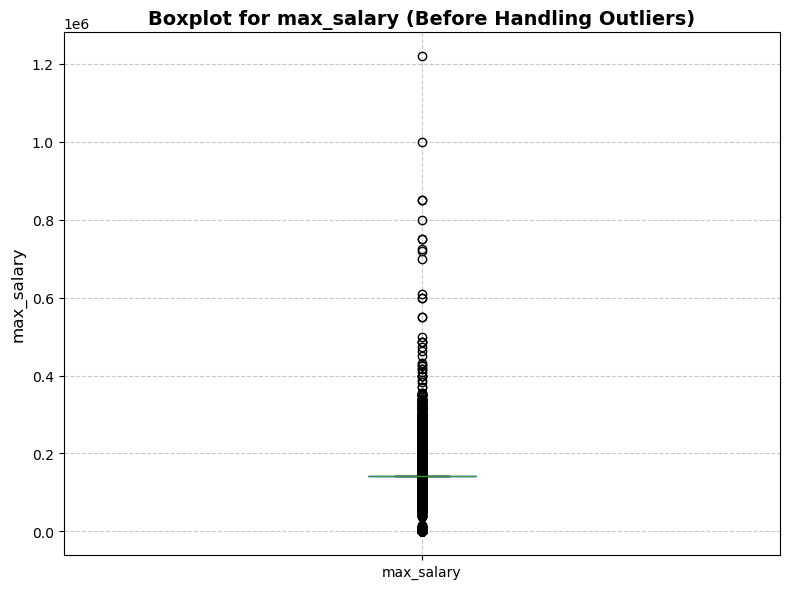

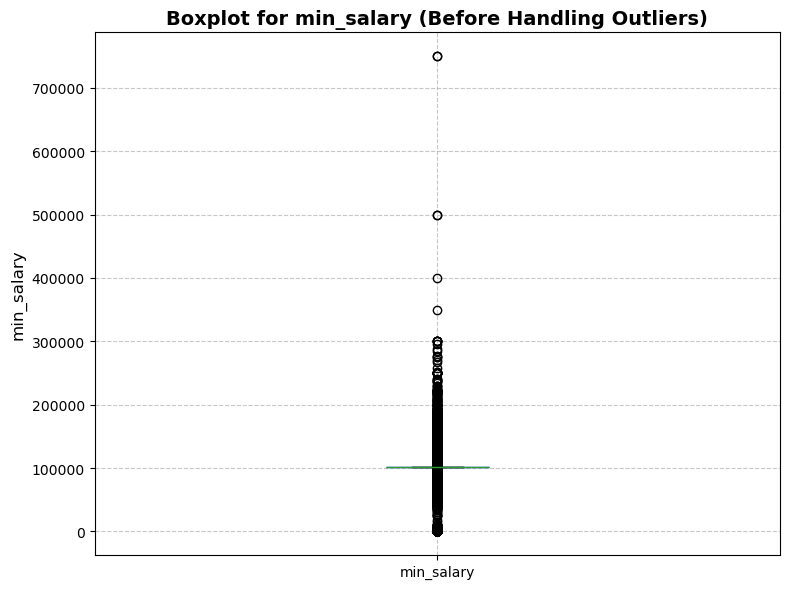

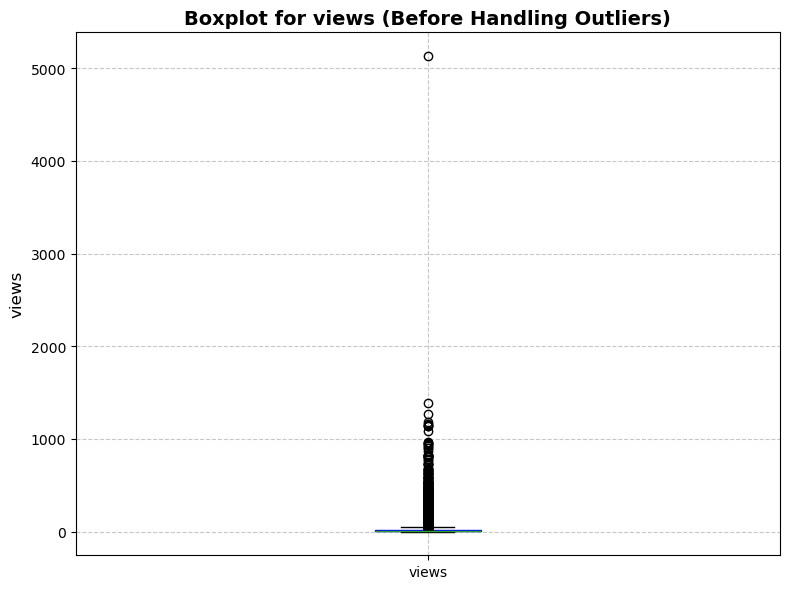

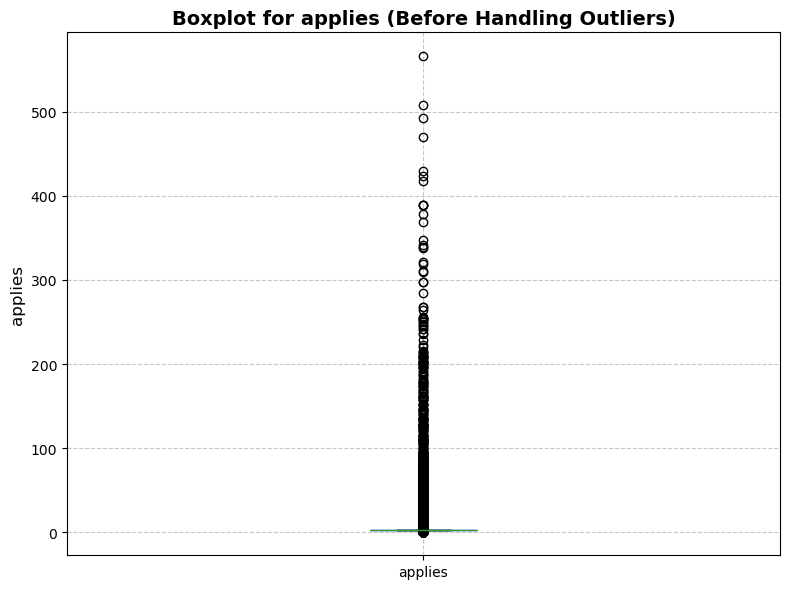

In [123]:
# Defining the numerical columns to check for outliers
numerical_columns = ['max_salary', 'min_salary', 'views', 'applies']

# Plot boxplots for each numerical column
for col in numerical_columns:
    plt.figure(figsize=(8, 6))
    final_df.boxplot(column=col, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))
    plt.title(f'Boxplot for {col} (Before Handling Outliers)', fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Objective:
The aim of this analysis was to visually detect potential outliers in key numerical columns, including:
- `max_salary`
- `min_salary`
- `views`
- `applies`

Boxplots were generated for each column to highlight data points that lie significantly outside the interquartile range (IQR). These outliers can influence the accuracy of insights, particularly when calculating averages or distributions.

Observations:
- **Salaries (`max_salary` and `min_salary`)**: A high number of extreme outliers suggest significant variability in salary ranges, with some values being disproportionately large.
- **Views**: A few extreme outliers reveal certain job postings received unusually high numbers of views.
- **Applies**: There is a heavy tail of application counts, indicating some postings attracted far more interest than others.

#### Conclusion:
Identifying these outliers is essential **before applying data transformations or visualising trends to ensure robust and accurate analysis**.


### Defining Functions To Identify & Handle Outliers Effectively
---

In [124]:
# Using bounds to identify outliers
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Defining a function that handles outliers effectively
def handle_outliers(data, column, method='remove'):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if method == 'remove':
        return data.loc[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    elif method == 'cap':
        data.loc[:, column] = data[column].clip(lower=lower_bound, upper=upper_bound)
        return data



In [125]:
numerical_columns = ['views', 'applies']

for col in numerical_columns:
    final_df = handle_outliers(final_df, col, method='cap')  
    print(f"Outliers in {col} handled.")


Outliers in views handled.
Outliers in applies handled.


I successfully identified and handled outliers in my dataset using the **IQR (Interquartile Range)** method. Here's how I did it:

1. I calculated the IQR for each numerical column to identify values that were considered outliers:
   - Outliers were any data points below **Q1 - 1.5 * IQR** or above **Q3 + 1.5 * IQR**.
   
2. I addressed these outliers using **capping**, where:
   - Any outlier below the lower bound was replaced with the lower bound.
   - Any outlier above the upper bound was replaced with the upper bound.

Outcome:
Outliers were successfully handled for the following columns:
- `views`
- `applies`

This step ensures my dataset is clean, reliable, and ready for further analysis.


### Quick Check If Outliers Have Been Handled!
---

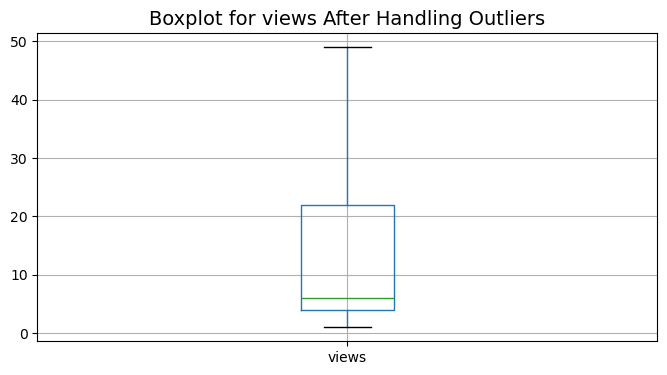

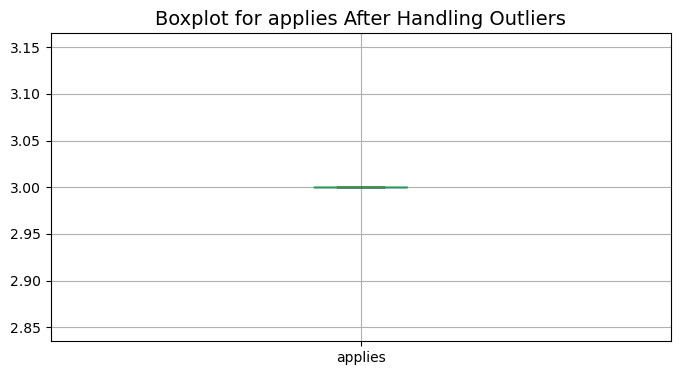

In [126]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    final_df.boxplot(column=col)
    plt.title(f'Boxplot for {col} After Handling Outliers', fontsize=14)
    plt.grid(True)
    plt.show()


  After applying the **IQR method** to detect and handle outliers using capping, the updated boxplots show a significant improvement:

  - **No visible outliers** remain in the boxplots.
  - The distributions are now well-bounded within the expected ranges.

  #### Observed Improvements:
  3. **views**: Unusual spikes have been capped, ensuring consistency.
  4. **applies**: Previously scattered outliers are now well-handled.

  #### Retaining Outliers for `max_salary` & `min_salary`
  ---
   I selectively chose to retain outliers for the max and min salary columns. This decision was made because certain job roles naturally exhibit extreme salary values, either very high or very low, based on industry norms or specialized skillsets. These values are not anomalies but rather represent valid and important data points that reflect the diversity of the job market.

By keeping these outliers, the dataset preserves its integrity and continues to provide an accurate representation of real-world salary distributions.

  This refined dataset ensures reliability for subsequent analyses and minimises the impact of skewed data.


# **Data Visualisation with MatPlotLib**
---
In this segment, I will utilise **Matplotlib** to create various visualizations that will help us explore the relationships and trends within the dataset. Visualization is a crucial part of the data analysis process, as it allows us to present complex data in a way that is both accessible and insightful.

### **Research Question**  
The central research question driving this analysis is:  
> ***"How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?"***

### **Purpose of Visualisation**  
By leveraging the power of **Matplotlib**, I will create visual representations that provide clear insights into:
1. **Salary Distributions**: Visualize how salary ranges differ across locations and experience levels.
2. **Work Type Breakdown**: Analyze the distribution of job types (e.g., full-time, part-time) in various geographic regions.
3. **Hiring Trends**: Examine how hiring trends vary across different locations and industries.
4. **Salary vs Experience Level**: Explore the relationship between salary and required experience level for various positions.

### **My Approach**  
In the following sections, I will generate a variety of charts, including:
- **Bar charts** to compare categorical data, such as job postings by location.
- **Boxplots** to visualize salary distributions and detect outliers.
- **Pie charts** to represent the breakdown of work types across locations.
- **Scatter plots** to analyze correlations, like salary and experience level.

These visualizations will provide meaningful insights into salary expectations, experience requirements, and hiring trends across geographic locations, helping to address the research question effectively.


# **1. Pie Chart: Most Requested IT-Related Skills in Job Postings**
---

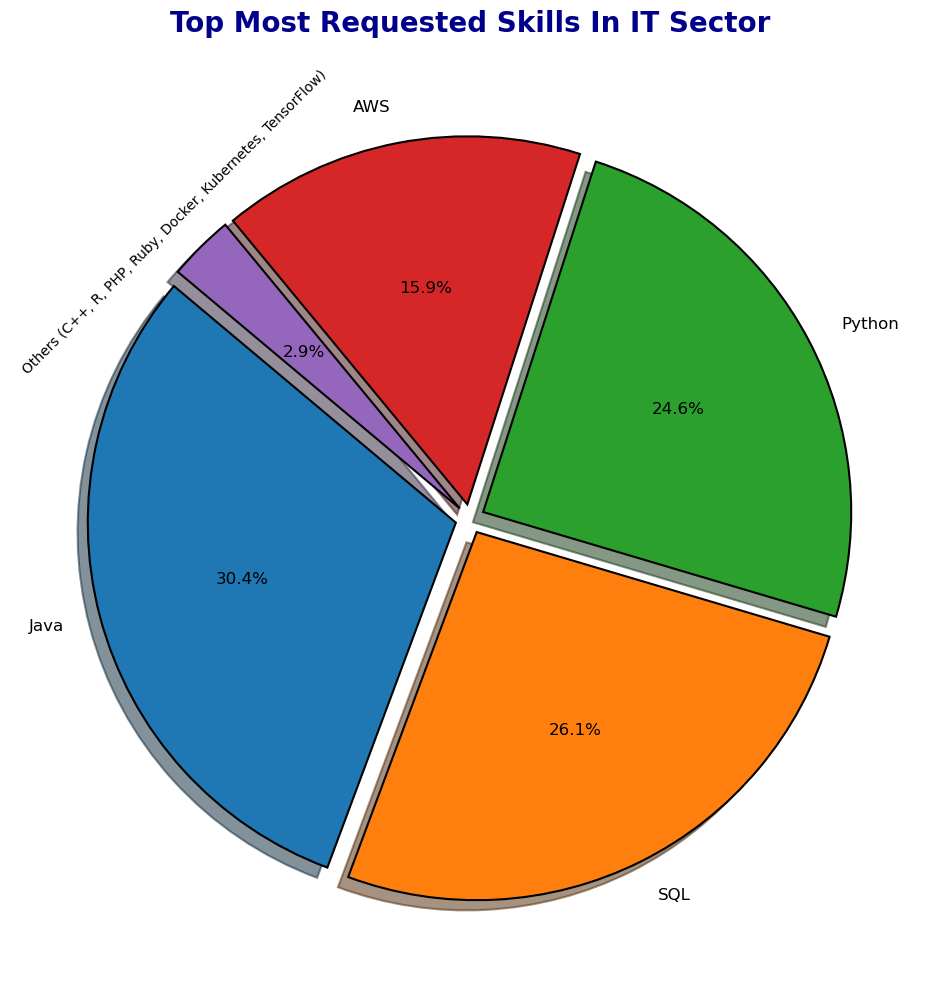

In [140]:
# Defining the skill keywords to filter
skill_keywords = ['Python', 'Java', 'JavaScript', 'SQL', 'C++', 'R', 'PHP', 'Ruby', 'AWS', 'Docker', 'Kubernetes', 'TensorFlow']

# Filter and count the occurrences of skills
skills = final_df['skills_desc'].dropna().str.split(',').explode().str.strip()
skills_counts = skills[skills.isin(skill_keywords)].value_counts()

# Group less frequent skills into "Others", putting a threshold of count (10)
threshold = 10
top_skills = skills_counts[skills_counts >= threshold]
top_skills['Others (C++, R, PHP, Ruby, Docker, Kubernetes, TensorFlow)'] = skills_counts[skills_counts < threshold].sum()

# Create the figure
plt.figure(figsize=(12, 10))

# Define explode for emphasis
explode = [0.04 for skill in top_skills.index]  

# Plot the pie chart with custom styling
wedges, texts, autotexts = plt.pie(
    top_skills,
    labels=top_skills.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.tab10(range(len(top_skills))),  # Use a vibrant color palette
    explode=explode,
    shadow=True,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'color': 'black'}
)

# Adjust the label for "Others" to tilt proportionally
for i, text in enumerate(texts):
    if "Others" in text.get_text():
        text.set_rotation(45)
        text.set_ha('center')  # Center the alignment for readability
        text.set_fontsize(10)  # Reduce font size for clarity
# Add a detailed title
plt.title('Top Most Requested Skills In IT Sector', fontsize=20, fontweight='bold', color='darkblue', pad=20)

plt.tight_layout()

plt.show()


This pie chart visualises the **distribution of the top-requested IT-related skills** in job postings. It directly contributes to answering the research question:
> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

By focusing on **skills**, this visualisation provides valuable insights into the most in-demand technical abilities across the IT job market, helping students and job seekers align their learning with industry requirements.

---

### Explanation of the Code

1. **Skill Extraction**:
   - Data is sourced from the `skills_desc` column in the dataset.
   - Skills are identified and categorised into key technical skills such as `Python`, `Java`, `AWS`, `SQL`, and others.

2. **Skill Categorisation**:
   - Skills with fewer than 10 occurrences are grouped into an "Others" category for simplicity and to avoid cluttering the chart with too many rare skills.

3. **Pie Chart Generation**:
   - The **pie chart** shows the percentage of job postings requesting each skill.
   - The most requested skills are highlighted, with **Python** representing the largest share of 24.6%, followed by **Java** and **SQL** at 30.4% and 26.1%, respectively.
   - **AWS** and **Others** (representing multiple smaller skills like `C++`, `R`, `Ruby`, `Docker`, etc.) are also represented.

4. **Styling and Annotations**:
   - The chart uses vibrant colours and shadow effects to enhance its visual appeal.
   - Each segment is annotated with its percentage to make the data easy to interpret at a glance.
   - A **title** provides clarity about the chart’s purpose, focusing on **the top-requested IT skills**.

---

### Insights from the Visualisation

The pie chart reveals the **relative demand for key technical skills** in IT job postings:
- **Python** leads with 24.6%, showcasing its dominance as one of the most requested programming languages across various regions.
- **Java** follows closely with 30.4%, highlighting its continued importance in software development roles.
- **SQL** accounts for 26.1%, reflecting the need for expertise in databases and data management.
- **AWS** represents 15.9%, demonstrating the growing demand for cloud-related skills, while the **Others** category (2.9%) includes less common but still relevant technologies like `C++`, `R`, `Ruby`, and `TensorFlow`.

---

### Relevance to the Research Question

This visualisation plays an essential role in answering the research question by shedding light on the **required skills** in IT job postings. By highlighting the most in-demand skills, it helps to understand how different regions prioritise technical abilities.

#### Key Contributions to the Research Question:
1. **Market Trends**:
   - The chart demonstrates which technical skills are most in demand across the IT job market, providing insight into the **skills** that employers prioritise in different geographic locations.

2. **Career Development**:
   - Aspiring IT professionals can use this visualisation to focus on **high-demand skills** such as Python, Java, and AWS, aligning their career development with the needs of the industry.

3. **Bridging Skill Gaps**:
   - Educators and organisations can use these insights to adjust **curriculum** or develop **training programmes** that focus on the technical skills most sought after in IT job postings.

---

### Conclusion

This analysis helps job seekers and students make informed decisions about which technical skills to prioritise in their learning. By understanding the demand for certain skills, such as **Python**, **AWS**, and **SQL**, they can better align their expertise with industry requirements, enhancing their chances of securing jobs in the competitive IT job market.


# **2. Bar Chart: Average Salary By Experience Level**
---

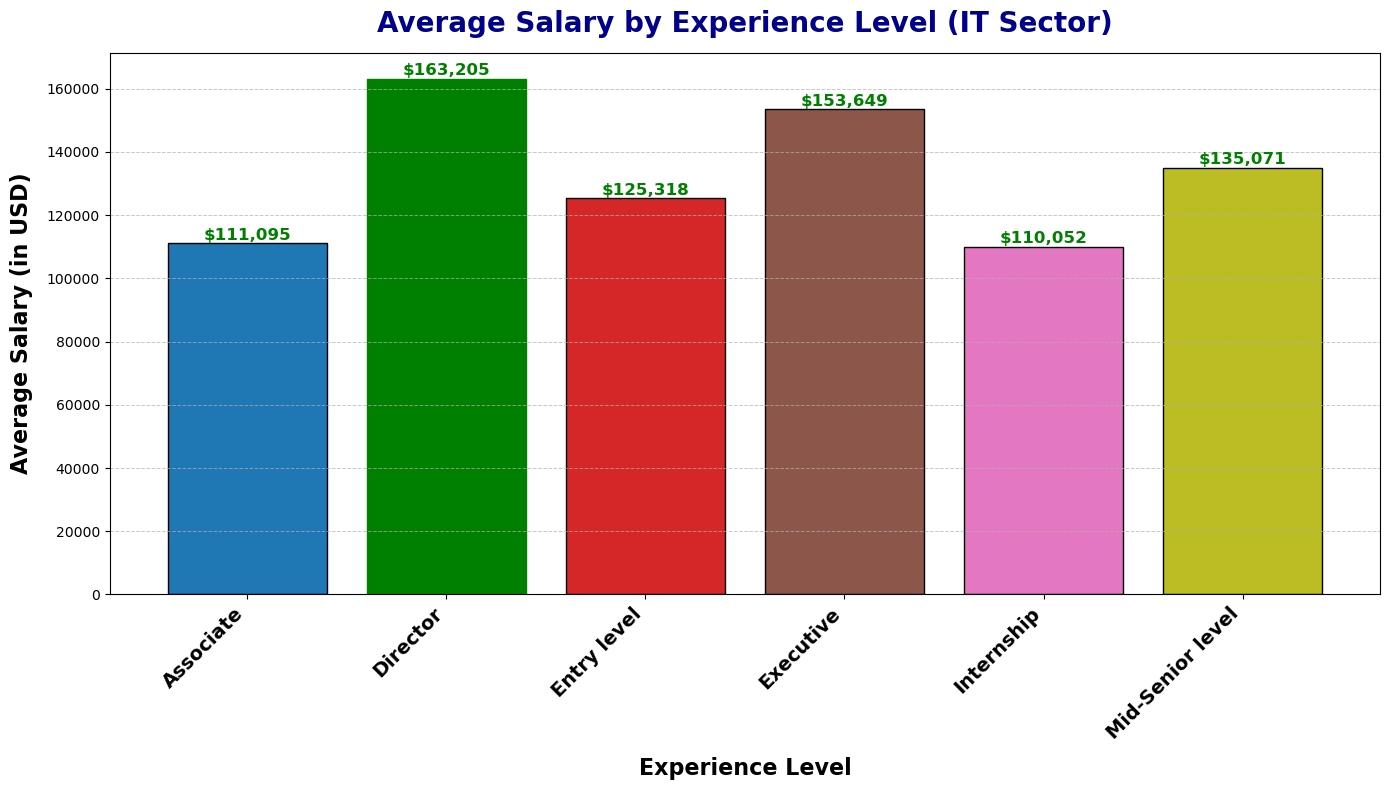

In [ ]:
# Calculate average salary by experience level
avg_salary_by_experience = final_df.groupby('formatted_experience_level')['max_salary'].mean()

# Defining a colormap using the new method (Got this from matplotlib documentation)
cmap = plt.colormaps['tab10']

# Create the figure
plt.figure(figsize=(14, 8))

# Plot the bar chart with custom color palette
bars = plt.bar(
    avg_salary_by_experience.index,
    avg_salary_by_experience.values,
    color=[cmap(i / len(avg_salary_by_experience)) for i in range(len(avg_salary_by_experience))],
    edgecolor='black'
)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Title and labels with enhanced formatting
plt.title('Average Salary by Experience Level (IT Sector)', fontsize=20, fontweight='bold', color='darkblue', pad=15)
plt.xlabel('Experience Level', fontsize=16, fontweight='bold', labelpad=10)
plt.ylabel('Average Salary (in USD)', fontsize=16, fontweight='bold', labelpad=10)

# Customize x-ticks for better readability
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold', color='black')

# Annotate each bar with its value
for bar, value in zip(bars, avg_salary_by_experience.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
        f'${value:,.0f}',
        ha='center', fontsize=12, color='green', weight='bold'
    )

# Highlight the highest bar with a different color
max_index = avg_salary_by_experience.idxmax()
bars[list(avg_salary_by_experience.index).index(max_index)].set_color('green')


plt.tight_layout()

plt.show()


This bar chart displays the **average salary** for different **experience levels** in the IT sector, providing valuable insights into how salaries vary across various job roles. This analysis directly addresses the research question:
> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

By focusing on **experience levels**, this chart helps to highlight how salary expectations change based on the role and level of expertise.

---

### Explanation of the Plot

1. **Experience Levels**:
   The chart groups IT job postings by **experience level**. The key categories shown are:
   - **Associate**: Entry-level positions requiring limited professional experience.
   - **Director**: High-level managerial roles that typically require significant industry experience.
   - **Entry Level**: Junior positions for candidates starting their careers in IT.
   - **Executive**: Senior leadership roles with extensive expertise and decision-making responsibilities.
   - **Internship**: Temporary roles, often for students or recent graduates.
   - **Mid-Senior Level**: Positions for professionals with a few years of experience, often in a leadership or specialised technical role.

2. **Average Salary by Experience Level**:
   - **Director** positions have the highest average salary at **$163,205**, reflecting the high demand for senior professionals with extensive experience.
   - **Entry Level** and **Mid-Senior Level** positions earn an average of **$125,318** and **$135,071**, respectively, showing how experience impacts salary.
   - **Internships** and **Associate** roles are lower-paying, with average salaries of **$110,052** and **$111,095**. This is expected for entry-level positions or temporary roles that do not require significant professional experience.

3. **Colour Palette**:
   - The bar chart uses a vibrant colour scheme (from the **tab10** colormap), which makes it easier to differentiate between the experience levels. The highest salary bar (**Director**) is highlighted in **green** for emphasis.

4. **Salary Annotations**:
   - Each bar is annotated with the **average salary value**, displayed in **green** for better visibility. This helps the viewer quickly grasp the salary trends by experience level.

---

### Insights from the Visualisation

- **Salary Growth**: As expected, higher experience levels correlate with higher salaries. **Directors** and **Executives** enjoy significantly higher salaries than **Entry-level** or **Internship** positions.
- **Salary Distribution**: The **Mid-Senior Level** and **Entry Level** positions have salaries in the range of **$125,000 to $135,000**, reflecting the increasing demand for skilled professionals with several years of experience.
- **Internships and Entry-Level Roles**: These roles, typically filled by students or early-career professionals, have the lowest average salaries, which is typical for positions with limited responsibility and fewer required skills.

---

### Relevance to Research Question

This visualisation directly contributes to answering the research question by focusing on the **salary ranges** for different **experience levels** in the IT sector. It provides insights into:

1. **Geographic Salary Variations**: Although this chart doesn't directly compare salaries across geographic locations, it offers a foundation for understanding how experience affects salaries. Geographic differences can be further explored in conjunction with this data to assess salary ranges in specific regions.
2. **Hiring Trends**: The salary trends reflect the demand for more experienced roles, suggesting that the IT industry prioritises hiring individuals with higher expertise for higher-paying roles like **Director** and **Executive**.
3. **Career Development**: For job seekers, this chart helps identify the salary expectations for various experience levels, guiding them in career planning and skill development.

---

### Conclusion

This bar chart illustrates the significant differences in **average salaries** across experience levels in the IT sector. It highlights the importance of gaining experience and advancing through different career stages to achieve higher salaries. For aspiring IT professionals, this data can help prioritise career development and skill acquisition, ensuring better alignment with industry demands and salary expectations.


## **3. Histogram: Salary Distribution Across IT Job Postings**
---

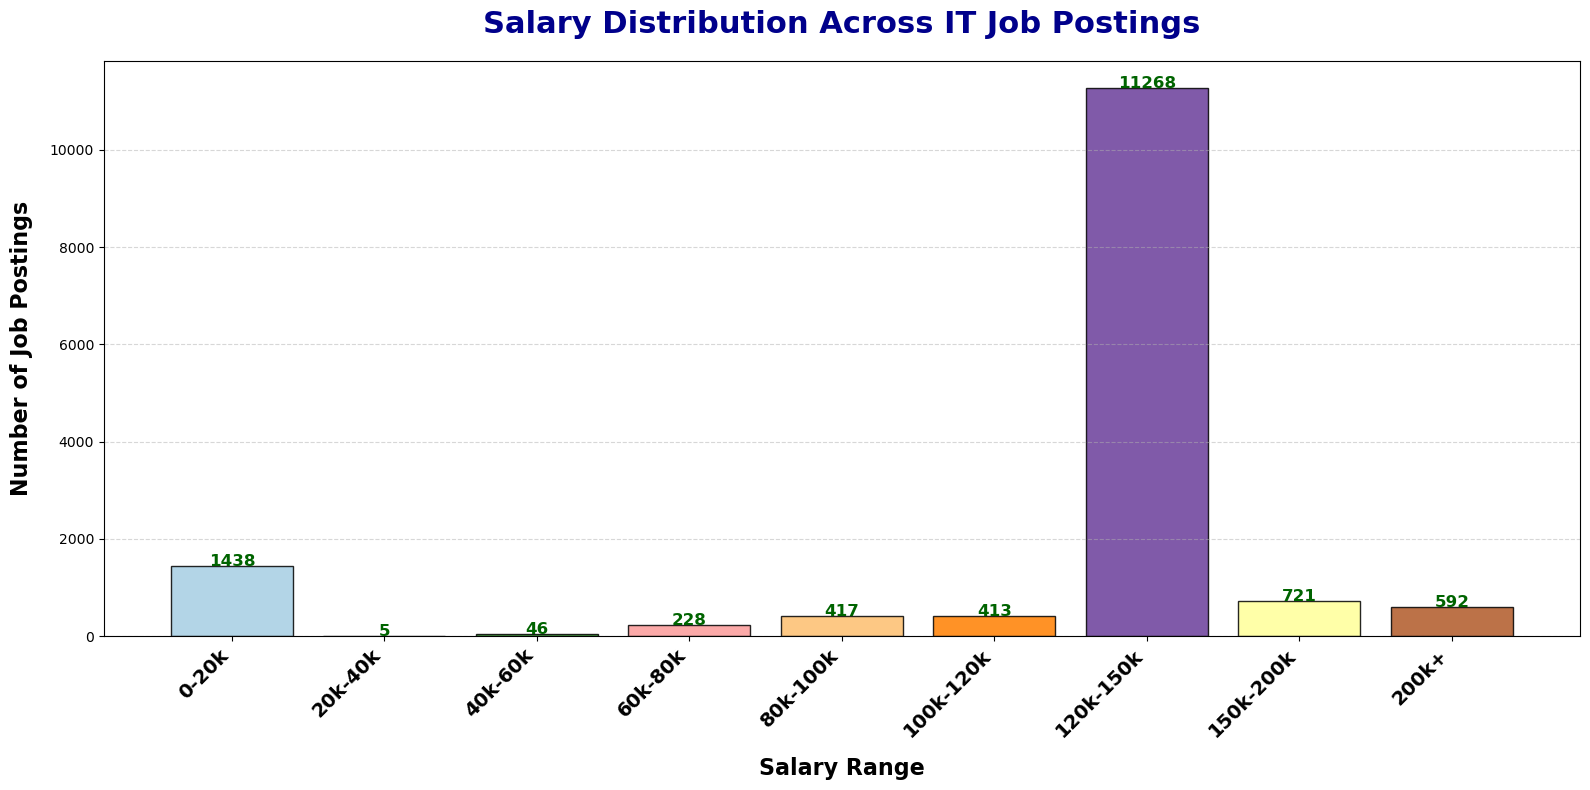

In [ ]:
# Ensure final_df is a true copy of the DataFrame
final_df = final_df.copy()

bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 150000, 200000, float('inf')]

labels = ['0-20k', '20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k-120k', '120k-150k', '150k-200k', '200k+']

# Use .loc[] to add a new salary_range column explicitly
final_df.loc[:, 'salary_range'] = pd.cut(final_df['max_salary'], bins=bins, labels=labels)

# Count the number of occurrences for each salary range
salary_range_counts = final_df['salary_range'].value_counts().sort_index()

# Visualization with improvements!!
plt.figure(figsize=(16, 8))

# Use a better colour map and give the bars a soft gradient
bar_colors = plt.cm.Paired(np.linspace(0, 1, len(salary_range_counts)))

# Create the histogram
bars = plt.bar(salary_range_counts.index, salary_range_counts.values, color=bar_colors, edgecolor='black', alpha=0.85)

# Customise plot with improved labels and title
plt.title('Salary Distribution Across IT Job Postings', fontsize=22, fontweight='bold', color='darkblue', pad=20)
plt.xlabel('Salary Range', fontsize=16, fontweight='bold', labelpad=12)
plt.ylabel('Number of Job Postings', fontsize=16, fontweight='bold', labelpad=12)
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add count labels on top of each bar 
for i, value in enumerate(salary_range_counts.values):
    plt.text(i, value + 0.5, str(value), ha='center', fontsize=12, fontweight='bold', color='darkgreen')

plt.tight_layout()

plt.show()


This bar chart visualises the **distribution of salaries** across IT-related job postings. It is categorised into defined salary ranges (e.g., `0-20k`, `20k-40k`, etc.) and provides insight into how IT salaries are distributed within the dataset. This analysis contributes directly to addressing the research question:

> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

By focusing on **salary ranges**, this chart helps us understand the prevalence of different salary levels and how they vary across roles.

---

### Insights from the Chart

1. **Salary Concentration**:
   - The majority of IT-related job postings fall into the `120k-150k` salary range, with **11,268 postings**, accounting for the highest number of jobs. This indicates a strong demand for mid-to-high-paying IT roles within this range.
   - Other salary ranges, such as `0-20k` (1,438 postings), highlight lower-paying roles, which might include entry-level positions, internships, or part-time jobs.
   - Salary ranges such as `20k-40k`, `40k-60k`, and `60k-80k` have very few postings, indicating that IT roles in these salary brackets are less common.

2. **High-End Salaries**:
   - There are still a notable number of postings in the `150k-200k` range (**721 postings**) and `200k+` range (**592 postings**), showcasing demand for highly skilled professionals or leadership roles in the IT sector.

3. **Diversity in Salary Distribution**:
   - The chart reveals the diversity in salary distribution, with a significant skew towards higher-paying roles in the `120k-150k` range, while entry-level or internship roles tend to fall in the `0-20k` range.

---

### How This Chart Helps Address the Research Question

This visualisation contributes to answering the research question by focusing on **salary ranges** within IT job postings:

1. **Understanding Salary Trends**:
   - It highlights the most common salary ranges, with the majority of roles falling in the mid-to-high range (`120k-150k`). This suggests that IT jobs generally offer competitive salaries, especially for skilled or experienced professionals.

2. **Identifying Hiring Patterns**:
   - The chart shows a clear distinction between lower-paying roles (`0-20k`) and higher-paying roles (`120k+`), indicating hiring trends for both entry-level and senior-level positions.
   - The lack of postings in mid-salary ranges (`40k-80k`) suggests that these salary bands may be less common in IT job markets.

3. **Implications for Job Seekers**:
   - For job seekers, this chart provides guidance on expected salaries for IT roles. For example, professionals aiming for leadership or highly skilled positions can target roles in the `150k-200k` and `200k+` ranges, while entry-level job seekers may focus on roles within the `0-20k` range.

4. **Geographic Variations**:
   - While this chart does not explicitly show geographic differences, it establishes a baseline for understanding salary ranges. Further analysis can compare these ranges across regions to explore location-specific salary trends.

---

### Conclusion

This salary distribution chart provides key insights into the salary expectations for IT-related job postings. It supports the research question by offering a detailed view of how salaries are structured across roles, enabling us to identify hiring patterns and salary trends. This data can guide job seekers, students, and employers in aligning their goals with industry standards.

By highlighting the most common salary ranges, this analysis builds a strong foundation for further exploration of geographic differences, hiring trends, and role-specific salaries in the IT sector.


## **4. Line Chart: Top 10 Locations By Median Salary (IT Sector)**
---

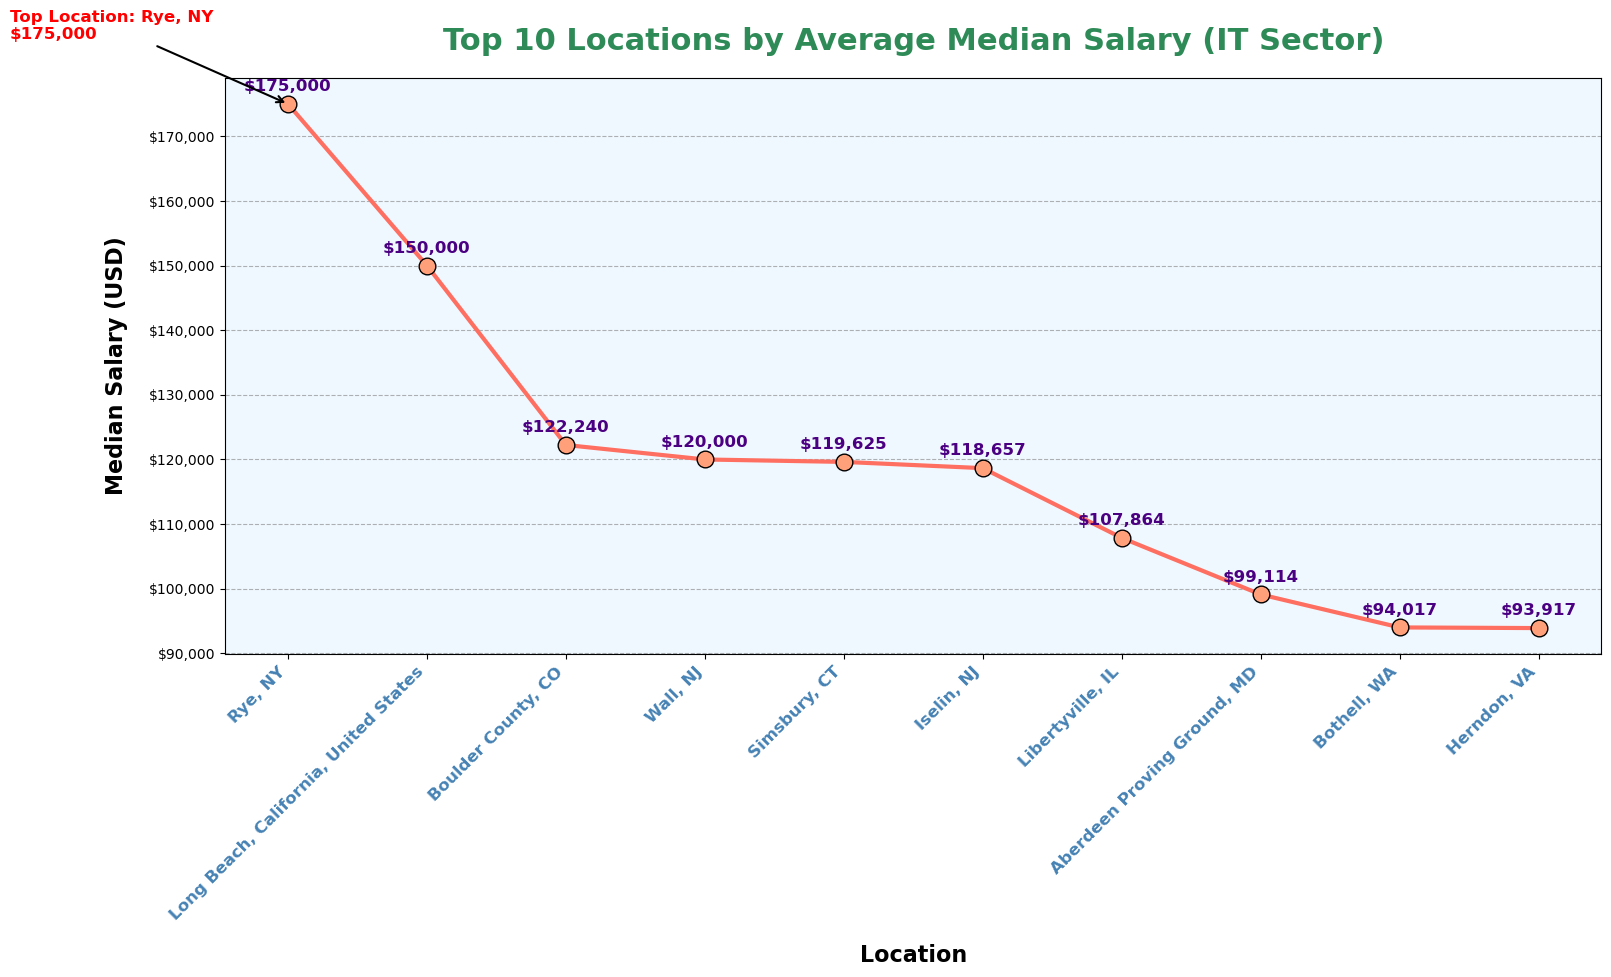

In [ ]:

# Aggregate the median salary by location
location_salary = final_df.groupby('location')['med_salary'].mean().sort_values(ascending=False).head(10)

# Create the figure
plt.figure(figsize=(16, 10))

# Plot the line chart
plt.plot(
    location_salary.index,
    location_salary.values,
    marker='o',
    linestyle='-',
    color='#FF6F61',  
    linewidth=3,
    markersize=12,
    markeredgecolor='black', 
    markerfacecolor='#FFA07A'  
)

# Add data labels on the points!!
for i, (location, salary) in enumerate(location_salary.items()):
    plt.text(
        i, salary + 2000, f"${salary:,.0f}",
        fontsize=12,
        color='#4B0082',  # Indigo color for labels
        ha='center',
        fontweight='bold'
    )

# Title and labels
plt.title('Top 10 Locations by Average Median Salary (IT Sector)', fontsize=22, fontweight='bold', color='#2E8B57', pad=20)  # SeaGreen title
plt.xlabel('Location', fontsize=16, fontweight='bold', color='black', labelpad=15)
plt.ylabel('Median Salary (USD)', fontsize=16, fontweight='bold', color='black', labelpad=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=12, ha='right', fontweight='bold', color='#4682B4')  # SteelBlue for x-ticks

# Customize y-axis with currency format! I included $ sign!
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Grid for better readability!
plt.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.6, color='gray')

# Highlighting the top location with a custom annotation
top_location = location_salary.idxmax()
top_salary = location_salary.max()
plt.annotate(
    f'Top Location: {top_location}\n${top_salary:,.0f}',
    xy=(0, top_salary), xytext=(-2, top_salary + 10000),
    fontsize=12, fontweight='bold', color='red',
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5)
)

plt.gca().set_facecolor('#F0F8FF')  # background

plt.tight_layout()

plt.show()


This line chart highlights the **top 10 locations** in terms of **average median salary** for IT-related job postings. It directly contributes to addressing the research question:
> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

By focusing on **geographic locations**, this chart provides valuable insight into where the highest-paying IT roles are located, helping job seekers and employers understand salary trends.

---

### Insights from the Chart

1. **Top Location**:
   - **Rye, NY** is the highest-paying location for IT jobs, with an average median salary of **$175,000**. This is significantly higher than the other locations on the list.
   - This insight highlights that certain regions, like **New York**, offer premium salaries for IT roles, likely due to high demand or local economic factors.

2. **Other High-Paying Locations**:
   - Locations like **Long Beach, CA** and **Boulder County, CO** also feature prominently, with salaries of **$150,000** and **$122,240**, respectively.
   - These regions are known for their strong IT industries, reflecting the competitive compensation offered to attract talent.

3. **Diversity in Salaries**:
   - The chart shows a gradual decline in average median salary as we move down the list, with the lowest in the top 10 being **Herndon, VA**, at **$93,917**.
   - This suggests that while there are lucrative IT opportunities in certain regions, salary expectations can vary significantly depending on location.

4. **Regional Insights**:
   - The mix of cities across states like New York, California, Colorado, and Virginia indicates that high-paying IT roles are not confined to a single region but are spread across different hubs in the United States.

---

### How This Chart Helps Address the Research Question

This visualisation plays a crucial role in answering the research question by focusing on **geographic salary trends**:

1. **Geographic Variation in Salaries**:
   - It clearly shows how IT salaries differ across locations, identifying regions that offer the most competitive compensation for IT professionals.

2. **Hiring Trends Across Locations**:
   - The chart highlights locations with higher salary offerings, which could indicate strong demand for IT talent in these areas. This insight helps job seekers target high-paying regions for their careers.

3. **Career Planning for IT Professionals**:
   - By identifying top-paying locations like **Rye, NY**, job seekers can better align their career goals and relocation plans with regions that offer lucrative opportunities.

4. **Economic Insights**:
   - The data provides employers and policymakers with a better understanding of salary benchmarks across regions, helping them attract and retain top IT talent.

---

### Conclusion

This chart provides a detailed view of the **top 10 locations by average median salary**, helping to address the research question by showing how IT job salaries vary geographically. The insights are particularly useful for job seekers aiming to maximise their earnings and for employers looking to remain competitive in attracting IT professionals.

By focusing on geographic salary trends, this visualisation highlights regions with lucrative opportunities, enabling better decision-making for both job seekers and organisations in the IT sector.


## **5. Scatter Plot: Applications VS Job Views (IT Sector)**
---

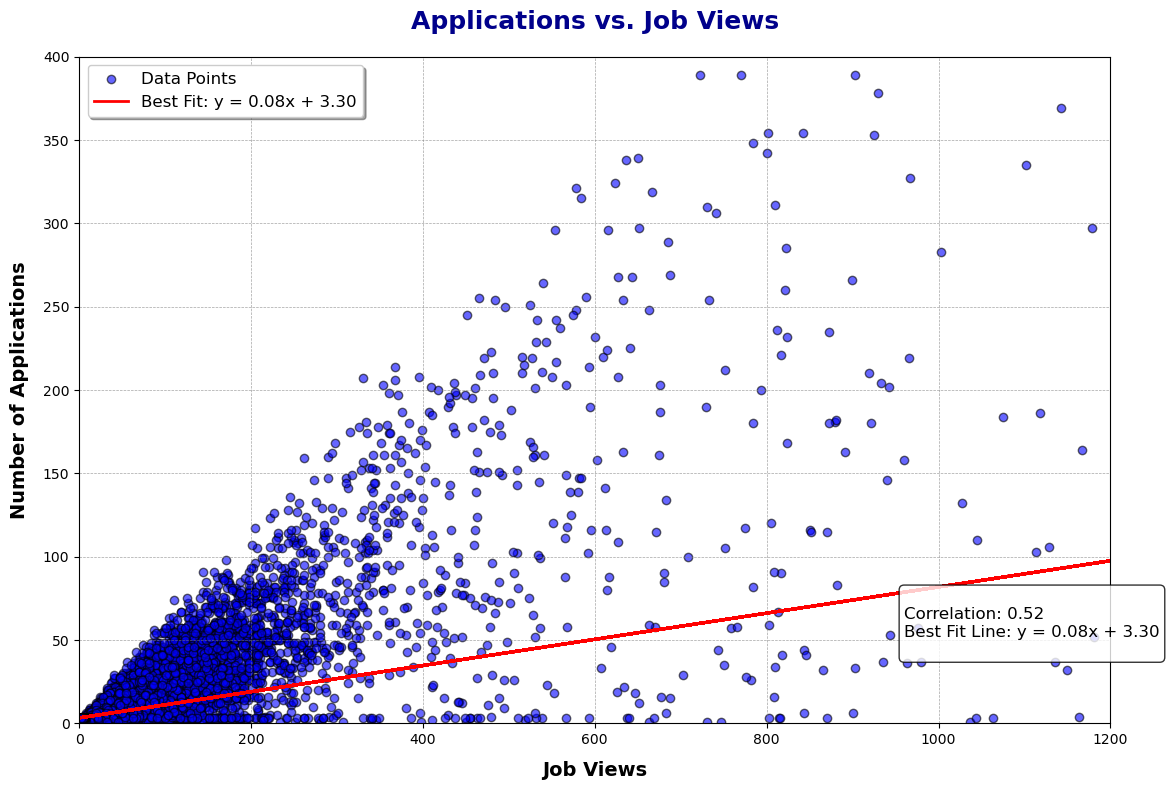

In [ ]:
# Impute missing values in 'applies' and 'views' using median with .loc to avoid warnings
cleaned_data.loc[:, 'applies'] = cleaned_data['applies'].fillna(cleaned_data['applies'].median())
cleaned_data.loc[:, 'views'] = cleaned_data['views'].fillna(cleaned_data['views'].median())

# Scatter plot data
x = cleaned_data['views']
y = cleaned_data['applies']

# Calculate the best-fit line
m, b = np.polyfit(x, y, 1)  # Linear regression: slope (m) and intercept (b)
best_fit = m * x + b

# Create the scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(x, y, color='blue', alpha=0.6, edgecolor='k', label='Data Points')

# Plot the best-fit line
plt.plot(x, best_fit, color='red', linewidth=2, label=f'Best Fit: y = {m:.2f}x + {b:.2f}')

# Add a title and labels
plt.title('Applications vs. Job Views', fontsize=18, fontweight='bold', color='darkblue', pad=20)
plt.xlabel('Job Views', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Number of Applications', fontsize=14, fontweight='bold', labelpad=10)

# Annotating the plot with a textbox for insights
correlation = np.corrcoef(x, y)[0, 1]  # Calculate correlation coefficient
textstr = f"""
Correlation: {correlation:.2f}
Best Fit Line: y = {m:.2f}x + {b:.2f}
"""
plt.gca().text(
    0.8, 0.2, textstr,
    transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Set axis limits for better readability
plt.xlim(0, 1200)
plt.ylim(0, 400)

# Add gridlines
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust legend placement to avoid overlap
plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()

plt.show()


#### Purpose
This scatter plot visualises the relationship between **job views** (how many times a job posting is viewed) and **applications** (how many people applied for the job). It provides valuable insights into hiring trends, particularly focusing on **candidate interest** based on job visibility.

#### Explanation of the Plot
1. **Scatter Plot**:
   - Each blue dot represents a unique job posting, plotting the number of views (x-axis) against the number of applications (y-axis).
   - A clear upward trend is noticeable, indicating a positive relationship between views and applications.

2. **Best-Fit Line**:
   - The red line represents the **best-fit linear regression**, summarised by the equation:
     \[
     y = 0.08x + 3.30
     \]
     where \(y\) is the number of applications, and \(x\) is the number of views.
   - This suggests that, on average, for every 100 additional job views, there are approximately **8 more applications**.

3. **Correlation**:
   - A **correlation coefficient of 0.52** indicates a moderate positive relationship between views and applications. This means more visibility often leads to higher applications, but it’s not a guarantee.

4. **Annotations**:
   - A textbox summarises the key metrics of the plot: the correlation coefficient and the best-fit line equation.
   - The scatter points are sized and styled to be visually appealing and easy to interpret.

5. **Axis Limits**:
   - The x-axis ranges from **0 to 1200 views**, while the y-axis is limited to **0 to 400 applications**, ensuring a focused view of the data.

#### How This Relates to the Research Question
The research question asks:
> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

This plot specifically addresses **hiring trends** by exploring the interaction between job posting visibility (views) and applicant interest (applications):
- **Hiring Trends**: The positive correlation suggests that jobs with higher visibility tend to attract more applications, which is crucial for understanding recruitment dynamics.
- **Practical Insights**: This insight could help recruiters optimise their postings to increase visibility and attract more candidates, especially in competitive IT sectors.

#### Conclusion
This scatter plot helps quantify the relationship between job posting views and applications, contributing to the overall analysis of hiring trends in IT-related job postings. It highlights the importance of job visibility as a factor in applicant interest, offering actionable insights for recruiters and job seekers.


## **6. Box Plot: Median Salary by Experience Level (IT Sector)**
---   

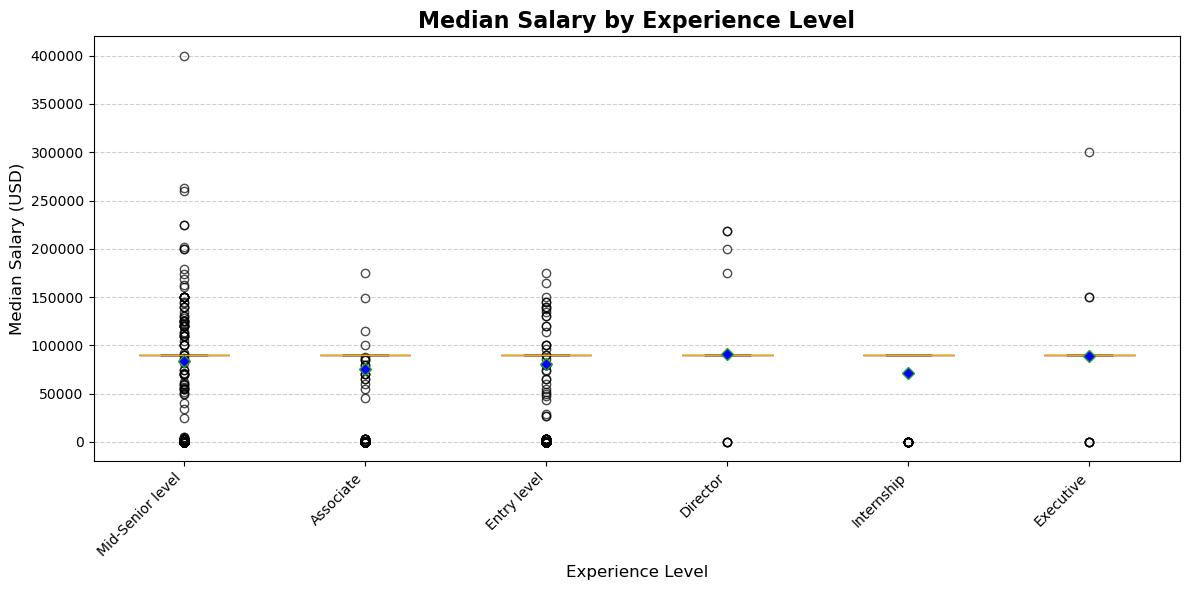

In [132]:
# Group median salary data by experience level
experience_levels = final_df['formatted_experience_level'].unique()
data_for_boxplot = [
    final_df[final_df['formatted_experience_level'] == level]['med_salary'] 
    for level in experience_levels
] # List Comprehension

# Create the box plot
plt.figure(figsize=(12, 6))
plt.boxplot(
    data_for_boxplot,
    patch_artist=True,  
    labels=experience_levels,
    showmeans=True,  
    flierprops={'marker': 'o', 'color': 'red', 'alpha': 0.7},  
    medianprops={'color': 'orange'}, 
    meanprops={'marker': 'D', 'markerfacecolor': 'blue'}  
)

# Add labels and title
plt.title('Median Salary by Experience Level', fontsize=16, fontweight='bold')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.grid(axis='y', linestyle='--', alpha=0.6)  

plt.tight_layout()
plt.show()


This box plot visualises the **distribution of median salaries** across different **experience levels** within IT-related job postings. It supports my research question:

> **How do IT-related job postings vary across geographic locations in terms of hiring trends, salary ranges, required skills, experience levels, and work types?**

---

### Insights from the Plot
1. **Salary Distributions**:
   - The plot clearly demonstrates the variation in salaries across **experience levels** (e.g., **Entry Level**, **Mid-Senior**, **Executive**, etc.).
   - The **median salaries** are highlighted with orange lines, while the blue diamonds represent the **mean salaries**.
   - Outliers are depicted as red circles, providing insight into extreme salary values within each category.

2. **Comparative Analysis**:
   - **Internship** positions have the lowest salary distribution, as expected, while **Executive** and **Director** roles show higher median salaries.
   - **Mid-Senior Level** has a wider salary range, indicating significant variation based on the role and company.

3. **Clarity on Experience Level Trends**:
   - This plot allows us to **compare salary expectations** across experience levels, helping job seekers and professionals understand what to expect at each stage of their career.

---

### Relevance to Research Question
This box plot directly addresses the research question by:
1. **Salary Trends by Experience**:
   - Highlighting how salaries vary with **experience levels**.
   - Providing insights into the expected **salary ranges** for IT professionals.

2. **Career Insights**:
   - Offering actionable information for job seekers to align their experience level with salary expectations.
   - Supporting organisations in benchmarking salaries for roles at different levels.

3. **Data Interpretation**:
   - The outliers and distribution ranges indicate the influence of **company size**, **location**, and **role types**, which are key components of IT job trends.

This analysis helps **validate salary variations** within IT job postings, thereby contributing to the broader understanding of **IT hiring trends and salary structures** across experience levels.

---

### ***The "box" in the box plot might not show up because my dataset is very big, and the salary data is packed closely together. This could make the range between the middle (Q1 and Q3) too small to see clearly. Also, too many data points or outliers might be covering the box, making it hard to spot.***

## **7. Bar Plot: Top 10 IT Job Titles with Highest Postings**
---   

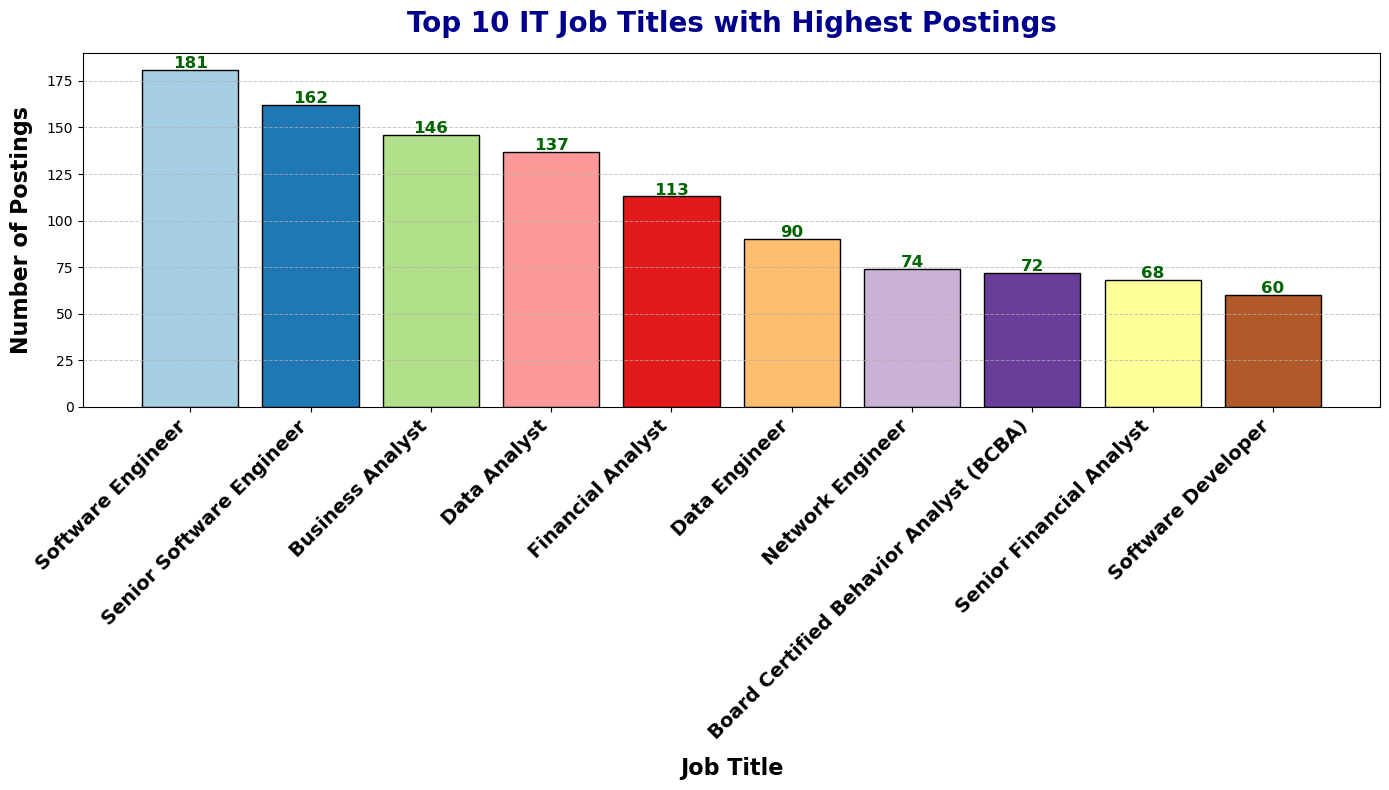

In [133]:
# Count job titles and take the top 10
top_titles = final_df['title'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(14, 8))
bars = plt.bar(
    top_titles.index,
    top_titles.values,
    color=plt.cm.Paired(np.linspace(0, 1, len(top_titles))),
    edgecolor='black'
)

# Add title and axis labels
plt.title('Top 10 IT Job Titles with Highest Postings', fontsize=20, fontweight='bold', color='darkblue', pad=15)
plt.xlabel('Job Title', fontsize=16, fontweight='bold', labelpad=10)
plt.ylabel('Number of Postings', fontsize=16, fontweight='bold', labelpad=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height + 1,  # Slightly above the bar
        f'{int(height)}',  
        ha='center', fontsize=12, fontweight='bold', color='darkgreen'
    )

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)\

plt.tight_layout()

plt.show()


This bar chart highlights the **Top 10 IT Job Titles with the Highest Postings**, providing insights into hiring trends within the IT sector:

1. **Key Insights**:
   - It identifies which IT roles (e.g., Software Engineer, Business Analyst) are in highest demand.
   - It enables aspiring IT professionals and students to align their skills and career aspirations with the most commonly advertised roles.
   - It helps educators and training providers design curricula that cater to the most sought-after roles in the market.

2. **Relevance to Research Question**:
   - This plot addresses the **hiring trends** component of the research question by illustrating the demand for specific roles across the IT sector.
   - It complements analyses of salary ranges and skills by showing which roles are most abundant in the market.

---

### Implementation

**Steps Taken to Create the Plot**:
1. **Data Preparation**:
   - The `title` column was analysed to count the frequency of job titles.
   - The top 10 most common job titles were extracted using `.value_counts().head(10)`.

2. **Plot Customisation**:
   - A **bar plot** was created using `matplotlib`.
   - A **gradient colour scheme** was applied for visual appeal.
   - Titles and axis labels were formatted to ensure readability and clarity.
   - **Exact posting counts** were displayed above each bar for additional context.
   - Gridlines and tight layout adjustments were included to enhance readability.

This plot visually conveys the relative demand for specific IT job titles and serves as a great way for deeper analysis into geographic or salary variations tied to these roles.


## **8. Histogram: Distribution of Maximum Salaries in Top 6 IT Job Locations**
---   

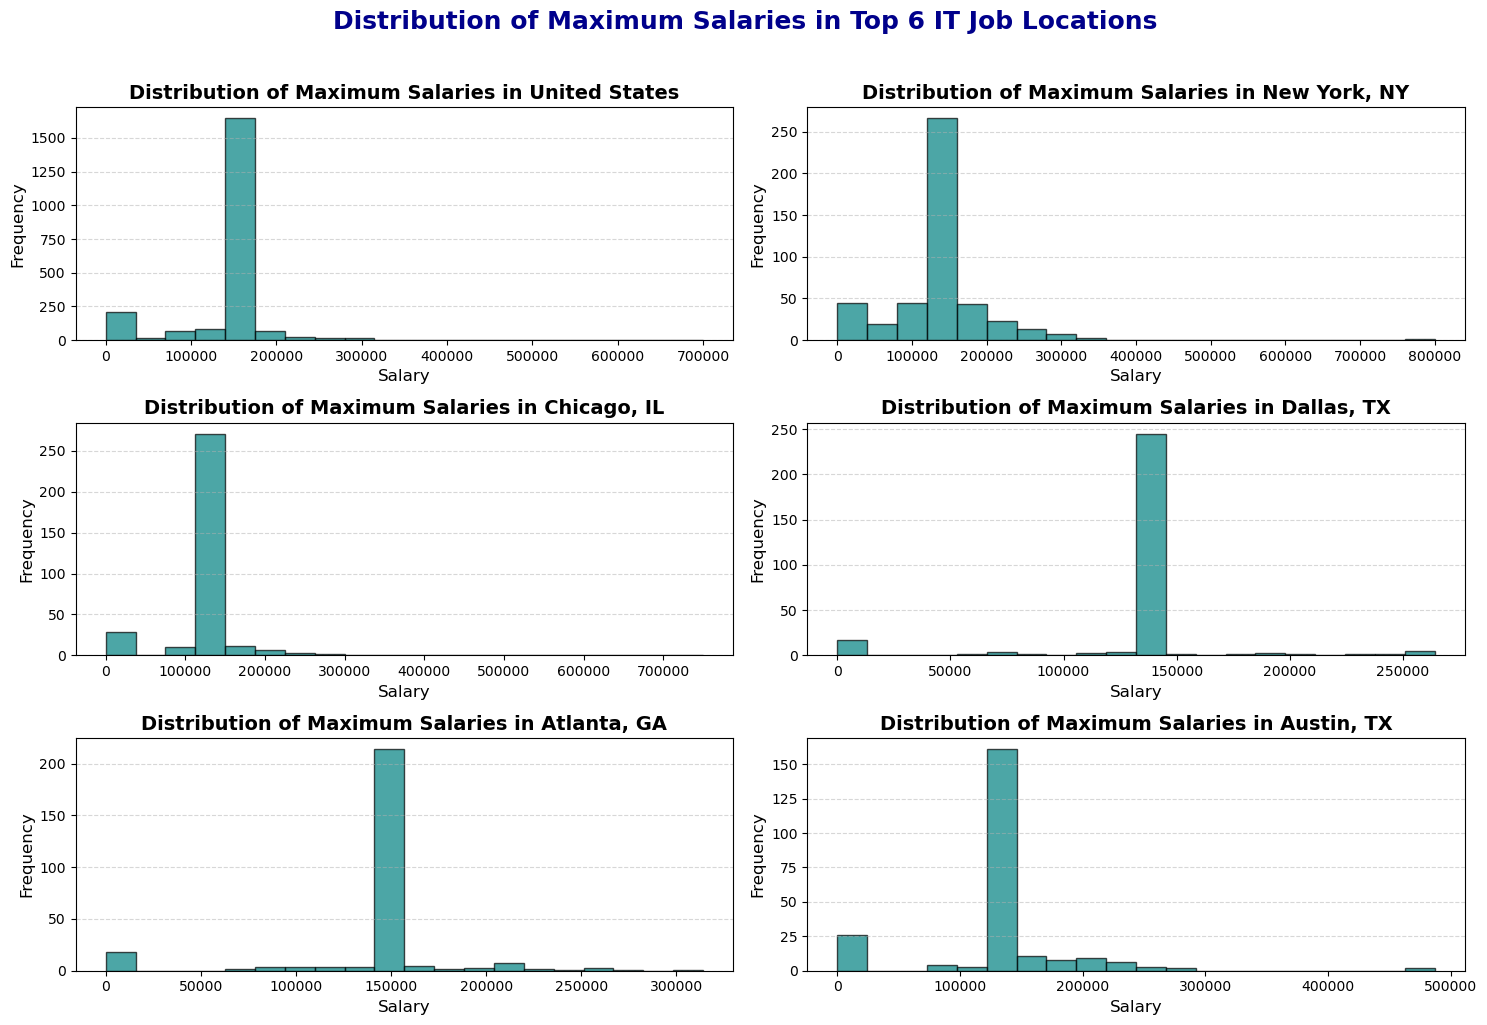

In [134]:
# Top 6 Locations, Distribution of Maximum Salaries
top_locations = final_df['location'].value_counts().head(6).index  
plt.figure(figsize=(15, 10))

for i, loc in enumerate(top_locations):
    plt.subplot(3, 2, i + 1)
    salaries = final_df[final_df['location'] == loc]['max_salary']
    plt.hist(salaries, bins=20, color='teal', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of Maximum Salaries in {loc}', fontsize=14, fontweight='bold')
    plt.xlabel('Salary', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribution of Maximum Salaries in Top 6 IT Job Locations', 
             fontsize=18, fontweight='bold', color='darkblue', y=1.02)
plt.tight_layout()
plt.show()


#### Insights From the Histograms:
1. **Salary Ranges**:  
   The histograms show the maximum salaries offered in the top 6 IT job locations. They help identify:
   - Which locations offer the highest salaries.
   - The variability of salaries within each location.
   
2. **Geographic Trends**:  
   By comparing the salary distributions across locations, we can see:
   - Regions with the most lucrative job opportunities.
   - Areas where salary ranges are more consistent or highly variable.

This helps answer the research question by highlighting how salaries differ across locations, giving insight into hiring trends and regional compensation differences in IT jobs.


# ***Conclusions***
___

The research aimed to understand how IT job postings differ in terms of hiring trends, salaries, required skills, experience levels, and work types. The following analysis, supported by visual data, provides clear insights:

## 1. Hiring Trends
The **Top 10 IT Job Titles** chart shows that roles like **Software Engineer**, **Senior Software Engineer**, and **Business Analyst** are the most common. Key findings include:
- **Software Engineer** is the most in-demand role, with 181 postings.
- Senior roles, such as **Senior Software Engineer**, highlight the high demand for experienced professionals.

---

## 2. Salary Ranges
The **Median Salary by Experience Level** and **Salary Distribution Across IT Job Postings** charts provide insights into salary trends:
- Locations like **Rye, NY** offer the highest average salaries, with £175,000 per year, showing that some regions provide significantly better pay.
- Most IT job salaries range between £100k-£150k, with over 11,000 postings in this range.
- Salary increases with experience:
  - **Directors** and **Executives** earn the highest average salaries (£163,205 and £153,649).
  - Entry-level positions and internships offer salaries between £110,000-£125,000.
- The **Histogram of Maximum Salaries by Location** provides additional insights into how the upper salary ranges vary geographically. It shows which regions have the most lucrative job offers and how these distributions differ across the top IT job locations.

---

## 3. Required Skills
The **Top Skills in IT** pie chart shows the most requested abilities:
- **Java** (30.4%) and **SQL** (26.1%) are the most in-demand skills, accounting for over half of all postings.
- **Python** (24.6%) is also widely requested, reflecting its importance in IT and data science.
- Cloud technologies like **AWS** (15.9%) highlight the growing demand for cloud-related skills.

---

## 4. Experience Levels
The **Median Salary by Experience Level** box plot shows:
- **Mid-Senior Level** roles make up a large part of the job postings, with salaries between £90,000 and £150,000.
- **Entry-level** roles are also common, giving graduates opportunities to enter the industry.

---

## 5. Work Types and Locations
From the **Top 10 Locations by Median Salary** chart:
- Locations such as **Rye, NY**, **Long Beach, CA**, and **Boulder County, CO** offer the highest salaries, often exceeding £120,000.
- Higher salaries are concentrated in regions known for their IT industries, highlighting the importance of location in determining pay.
- The **Histogram of Maximum Salaries by Location** adds further depth by showing salary distributions in these regions, highlighting both the range and frequency of high-paying roles.

---

The findings show significant differences in IT job postings across regions. Locations such as **Rye, NY**, **Long Beach, CA**, and **Boulder County, CO** are top spots for well-paid IT roles. Skills like **Java**, **SQL**, and **Python** are essential, while seniority plays a major role in salary levels. This analysis can help employers and job seekers make informed decisions about hiring strategies and career paths.
